# Kinase KD x CytoSignal LR-score EB spatial maps

This notebook visualizes kinase KD x CytoSignal LR-score interaction candidates at the EB level. It uses the completed project-wide FDR results from `Kinase_CytoSignal_TopLR_GeneLevel_OLS.ipynb` and the nine slide-level H5MU files with CytoSignal diffusion LR scores.

For each candidate, the plotted model is:

$$Y_g \sim KD_K + LR_s + KD_K 	imes LR_s$$

The main visual question is whether the LR-score/expression relationship differs between kinase-KD cells and no-guide/unperturbed controls within the same EB.


In [25]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import re
import warnings

import scipy.sparse as sp
import seaborn as sns
from matplotlib.lines import Line2D

import anndata as ad
import mudata as mu

warnings.filterwarnings('ignore', category=FutureWarning)
# Preserve labels, titles, tick labels, and legends as editable SVG/PDF text.
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 240)


## 1. Configuration

The notebook reads nine slide-level H5MU files and uses `slide::EB` as the EB identifier so EBs with the same label from different slides are not mixed. Candidate events come from the project-wide FDR output of the kinase CytoSignal Top-LR OLS notebook.


In [26]:
SLIDE_H5MU_DIR = Path('/scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu')
INPUT_H5MU_PATHS = {
    f'slide{i}': SLIDE_H5MU_DIR / f'slide{i}_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu'
    for i in range(1, 10)
}

RESULT_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_top5_lr_gene_level_ols_results')
PROJECTWIDE_FDR_POINTER = RESULT_DIR / 'projectwide_fdr_posthoc' / 'LATEST_PROJECTWIDE_FDR.json'
OUTPUT_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNA_MOD = 'rna'
LR_MOD = 'lr_cytosignal'
GUIDE_COLUMN = 'guides_passing_str'
EB_KEY = 'EB_cluster_manual'

RADIUS_LAYERS = {
    100: 'radius_100um',
    200: 'radius_200um',
    400: 'radius_400um',
}

# Internal aliases used to parse control/no-guide strings in the clean kinase files.
# In these data, the displayed 'NTC' string corresponds to no detected guide / unperturbed cells,
# not confirmed non-targeting sgRNA controls.
NTC_ALIASES = {'NTC', 'NEGATIVE CONTROL', 'NEGATIVE_CONTROL', 'NON-TARGETING', 'NON_TARGETING', 'NONTARGETING'}
CONTROL_DISPLAY_LABEL = 'no-guide/unperturbed'
MISSING_GUIDE_VALUES = {'', 'nan', 'none', 'na', 'NA', 'NaN', '<NA>'}
EXCLUDE_TARGET_LABELS = {'UNASSIGNED', 'NO_CRISPR_DATA'}
AMBIGUOUS_TARGET_LABELS = {'Unassigned', 'No_CRISPR_data', 'nan', '', 'none', 'NA', '<NA>'}

# Broad background controls used for EB ranking and the third trend line.
# 'not_current_target_exclude_ambiguous' = all cells except current KD cells, excluding ambiguous guide calls.
BROAD_CONTROL_MODE = 'not_current_target_exclude_ambiguous'

# Candidate-level definition. The model is:
#   gene expression ~ KD + LR_score + KD × LR_score
# Here beta_score is the LR-score slope in control cells, and beta_interaction is the KD-specific change in that LR-score slope.
MIN_ABS_KD_CONDITIONAL_LR_SLOPE = 0.02
MAX_PROJECTWIDE_FDR_INTERACTION = 0.05

# Single-candidate controls.
AUTO_FROM_TOP_CANDIDATE = True
CANDIDATE_RANK = 0
TARGET = 'MAPK8'
RADIUS_UM = 100
LR_VAR_NAME = 'CPI-CS040AEB4A0'
GENE = 'GENE'

# EB selection and plotting thresholds.
MIN_EB_CELLS = 30
INTERACTION_AWARE_MIN_KD_CELLS = 8
INTERACTION_AWARE_MIN_CONTROL_CELLS = 8
INTERACTION_AWARE_MIN_BROAD_CONTROL_CELLS = 30

# Plotting only: use a looser threshold so the figure shows the visual trend when possible.
VISUAL_TREND_MIN_CELLS = 2
DRAW_TREND_LINES_ON_COMMON_SCORE_RANGE = True
INTERACTION_AWARE_MIN_SCORE_SD = 1e-8

# EB-level interpretability filters.
MIN_GENE_EXPRESSED_FRACTION_ALL = 0.05
MIN_GENE_EXPRESSED_CELLS_ALL = 20
MIN_GENE_EXPRESSION_SD_ALL = 1e-8
MIN_LR_NONZERO_FRACTION_ALL = 0.05
MIN_LR_NONZERO_CELLS_ALL = 20
MIN_LR_SCORE_SD_ALL = 1e-8
MIN_GROUP_LR_NONZERO_FRACTION = 0.05
MIN_GROUP_GENE_EXPRESSED_CELLS = 3
MIN_GROUP_LR_NONZERO_CELLS = 3
LR_SCORE_NEAR_ZERO_EPS = 1e-12
TOP_EBS_PER_CANDIDATE = 3
N_INTERACTION_AWARE_CANDIDATES = 50

POINT_SIZE = 16
KD_POINT_SIZE = 90
KD_EDGE_WIDTH = 1.6
FIG_DPI = 220
SCORE_CMAP = 'viridis'
GENE_CMAP = 'magma'

assert all(path.is_file() for path in INPUT_H5MU_PATHS.values()), INPUT_H5MU_PATHS
assert RESULT_DIR.is_dir(), RESULT_DIR
assert PROJECTWIDE_FDR_POINTER.is_file(), PROJECTWIDE_FDR_POINTER
print('Input H5MU files:')
for slide, path in INPUT_H5MU_PATHS.items():
    print(' ', slide, path)
print('Result dir:', RESULT_DIR)
print('Project-wide FDR pointer:', PROJECTWIDE_FDR_POINTER)
print('Output:', OUTPUT_DIR)


Input H5MU files:
  slide1 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide2 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide3 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide4 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide5 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide6 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide7 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides

## 2. Load nine H5MU files and project-wide kinase candidates

This section aligns RNA and LR modalities, parses kinase targets from `guides_passing_str`, defines no-guide/unperturbed controls, and ranks project-wide significant `kinase x radius x LR score x gene` events for EB-level visualization.


In [6]:
def safe_name(x):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(x))


def normalize_token(x):
    if pd.isna(x):
        return ''
    return str(x).strip()


def split_guides(value):
    text = normalize_token(value)
    if not text or text.lower() in {v.lower() for v in MISSING_GUIDE_VALUES}:
        return []
    return [p.strip() for p in re.split(r'[;,|]+', text) if p.strip()]


def infer_target_from_guide(guide):
    text = normalize_token(guide)
    if not text:
        return ''
    upper = text.upper()
    if upper in NTC_ALIASES or re.search(r'NEGATIVE|NON[-_ ]?TARGET|\bNTC\b', upper):
        return 'NTC'  # internal control alias; display as no-guide/unperturbed
    token = re.split(r'[|:]', text)[0]
    token = re.sub(r'([._-]?g?RNA)?[._-]?(guide)?[._-]?\d+$', '', token, flags=re.I)
    token = re.sub(r'[._-](sg|g)\d+$', '', token, flags=re.I)
    return token.strip(' ._-').upper()


def guide_mapping_from_uns(uns):
    mapping = {}
    if uns is None or 'guide_protospacers' not in uns or 'gene_names_from_guides' not in uns:
        return mapping
    guides = np.asarray(uns['guide_protospacers']).astype(str)
    targets = np.asarray(uns['gene_names_from_guides']).astype(str)
    if len(guides) != len(targets):
        return mapping
    for guide, target in zip(guides, targets):
        guide = normalize_token(guide)
        target = normalize_token(target).upper() or infer_target_from_guide(guide)
        if guide:
            mapping[guide] = target
    return mapping


def map_guides_to_targets(value, guide_map):
    guides = split_guides(value)
    mapped = {guide_map.get(g, infer_target_from_guide(g)).upper() for g in guides}
    mapped.discard('')
    targets = tuple(sorted((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS))
    is_ntc_only = bool(mapped & NTC_ALIASES) and not bool((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS)
    return targets, is_ntc_only


def dense_vector(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()


def upper_gene_lookup(var_names):
    lookup = {}
    duplicates = set()
    for name in map(str, var_names):
        key = name.upper()
        if key in lookup and lookup[key] != name:
            duplicates.add(key)
        else:
            lookup[key] = name
    for key in duplicates:
        lookup.pop(key, None)
    return lookup


mdata_by_slide = {}
rna_blocks = []
lr_blocks = []
guide_map = {}
slide_qc_rows = []

for slide, path in INPUT_H5MU_PATHS.items():
    print(f'Loading {slide}: {path}')
    m = mu.read_h5mu(path)
    r = m.mod[RNA_MOD]
    l = m.mod[LR_MOD]
    common_cells = r.obs_names.intersection(l.obs_names)
    r = r[common_cells, :].copy()
    l = l[common_cells, :].copy()

    gm = guide_mapping_from_uns(r.uns)
    guide_map.update(gm)

    r.obs['source_slide'] = slide
    l.obs['source_slide'] = slide
    r.obs_names = [f'{slide}::{x}' for x in r.obs_names.astype(str)]
    l.obs_names = [f'{slide}::{x}' for x in l.obs_names.astype(str)]

    rna_blocks.append(r)
    lr_blocks.append(l)
    mdata_by_slide[slide] = m
    slide_qc_rows.append({
        'slide': slide,
        'path': str(path),
        'n_common_cells': len(common_cells),
        'rna_genes': r.n_vars,
        'lr_scores': l.n_vars,
        'guide_map_size': len(gm),
    })

rna = ad.concat(rna_blocks, axis=0, join='inner', merge='same', index_unique=None)
lr = ad.concat(lr_blocks, axis=0, join='inner', merge='same', index_unique=None)
slide_qc = pd.DataFrame(slide_qc_rows)

assert GUIDE_COLUMN in rna.obs.columns, GUIDE_COLUMN
target_info = [map_guides_to_targets(x, guide_map) for x in rna.obs[GUIDE_COLUMN].to_numpy()]
rna.obs['target_sets'] = pd.Series([x[0] for x in target_info], index=rna.obs_names, dtype='object')
rna.obs['is_control'] = pd.Series([x[1] for x in target_info], index=rna.obs_names, dtype=bool)

coords = np.asarray(rna.obsm['X_spatial'], dtype=float)
eb_raw = rna.obs[EB_KEY].astype(str).to_numpy()
slide_values = rna.obs['source_slide'].astype(str).to_numpy()
target_sets = rna.obs['target_sets'].to_numpy()
target_call = [';'.join(xs) if len(xs) else (CONTROL_DISPLAY_LABEL if is_ctrl else 'Unassigned') for xs, is_ctrl in zip(target_sets, rna.obs['is_control'].to_numpy(bool))]

plot_metadata = pd.DataFrame({
    'cell_id': rna.obs_names.astype(str),
    'source_slide': slide_values,
    'eb_label': eb_raw,
    'eb': [f'{s}::{e}' for s, e in zip(slide_values, eb_raw)],
    'target_sets': target_sets,
    'target_call': target_call,
    'is_control': rna.obs['is_control'].to_numpy(bool),
    'x': coords[:, 0],
    'y': coords[:, 1],
})
if 'cell_type' in rna.obs.columns:
    plot_metadata['cell_type'] = rna.obs['cell_type'].astype(str).to_numpy()

projectwide_metadata = json.loads(PROJECTWIDE_FDR_POINTER.read_text())
if projectwide_metadata.get('status') != 'completed':
    raise RuntimeError(f'Project-wide FDR is not complete: {projectwide_metadata}')
projectwide_run_dir = Path(projectwide_metadata['run_dir'])
projectwide_event_path = projectwide_run_dir / 'projectwide_top_interaction_events.csv.gz'
if not projectwide_event_path.is_file():
    projectwide_event_path = projectwide_run_dir / 'projectwide_significant_interaction_events.csv.gz'
if not projectwide_event_path.is_file():
    raise FileNotFoundError(projectwide_event_path)

best_candidates = pd.read_csv(projectwide_event_path)
required = {'target', 'radius_um', 'lr_var_name', 'gene', 'fdr_interaction_projectwide'}
missing = required - set(best_candidates.columns)
if missing:
    raise RuntimeError(f'Missing required candidate columns: {missing}')

best_candidates['target'] = best_candidates['target'].astype(str).str.upper()
best_candidates['radius_um'] = best_candidates['radius_um'].astype(int)
best_candidates['lr_var_name'] = best_candidates['lr_var_name'].astype(str)
best_candidates['gene'] = best_candidates['gene'].astype(str)
if 'beta_lr' not in best_candidates.columns and 'beta_score' in best_candidates.columns:
    best_candidates['beta_lr'] = best_candidates['beta_score']
if 'p_lr' not in best_candidates.columns and 'p_score' in best_candidates.columns:
    best_candidates['p_lr'] = best_candidates['p_score']

for col in ['beta_lr', 'beta_score', 'beta_interaction', 'fdr_interaction_projectwide']:
    if col in best_candidates.columns:
        best_candidates[col] = pd.to_numeric(best_candidates[col], errors='coerce')

ligand_text = best_candidates.get('ligand_name', pd.Series('', index=best_candidates.index)).fillna('').astype(str).str.strip()
receptor_text = best_candidates.get('receptor_name', pd.Series('', index=best_candidates.index)).fillna('').astype(str).str.strip()
lr_name_text = best_candidates.get('lr_name', pd.Series('', index=best_candidates.index)).fillna('').astype(str).str.strip()
best_candidates['lr_display_name'] = np.where(
    ligand_text.ne('') & receptor_text.ne(''),
    ligand_text + ' -> ' + receptor_text,
    np.where(lr_name_text.ne(''), lr_name_text, best_candidates['lr_var_name']),
)

best_candidates = best_candidates.loc[
    best_candidates['fdr_interaction_projectwide'].lt(MAX_PROJECTWIDE_FDR_INTERACTION)
].copy()
if best_candidates.empty:
    raise RuntimeError('No kinase candidate passed project-wide interaction FDR threshold.')

best_candidates['kd_conditional_lr_slope'] = best_candidates.get('beta_lr', np.nan) + best_candidates['beta_interaction']
best_candidates['abs_kd_conditional_lr_slope'] = best_candidates['kd_conditional_lr_slope'].abs()
best_candidates['abs_beta_interaction'] = best_candidates['beta_interaction'].abs()
best_candidates['map_rank_score'] = (
    -np.log10(best_candidates['fdr_interaction_projectwide'].clip(lower=1e-300))
    * best_candidates['abs_beta_interaction']
    * best_candidates['abs_kd_conditional_lr_slope'].clip(lower=1e-6)
)
if MIN_ABS_KD_CONDITIONAL_LR_SLOPE is not None:
    best_candidates = best_candidates.loc[
        best_candidates['abs_kd_conditional_lr_slope'].ge(MIN_ABS_KD_CONDITIONAL_LR_SLOPE)
    ].copy()

best_candidates = best_candidates.sort_values(
    ['map_rank_score', 'abs_beta_interaction', 'fdr_interaction_projectwide'],
    ascending=[False, False, True],
    ignore_index=True,
)
ranked_candidate_path = OUTPUT_DIR / 'kinase_lr_map_projectwide_candidate_ranked.csv.gz'
best_candidates.to_csv(ranked_candidate_path, index=False, compression='gzip')

if AUTO_FROM_TOP_CANDIDATE:
    candidate_row = best_candidates.iloc[CANDIDATE_RANK]
    TARGET = str(candidate_row['target'])
    RADIUS_UM = int(candidate_row['radius_um'])
    LR_VAR_NAME = str(candidate_row['lr_var_name'])
    GENE = str(candidate_row['gene'])
else:
    manual_match = best_candidates.loc[
        best_candidates['target'].eq(str(TARGET).upper())
        & best_candidates['radius_um'].eq(int(RADIUS_UM))
        & best_candidates['lr_var_name'].eq(str(LR_VAR_NAME))
        & best_candidates['gene'].eq(str(GENE))
    ]
    if manual_match.empty:
        raise ValueError(
            'Manual candidate is not an eligible kinase-target event with '
            f'project-wide interaction FDR < {MAX_PROJECTWIDE_FDR_INTERACTION}: '
            f'{TARGET}, {RADIUS_UM}, {LR_VAR_NAME}, {GENE}'
        )
    candidate_row = manual_match.iloc[0]

print('Combined RNA:', rna.shape)
print('Combined LR:', lr.shape)
print('No-guide/unperturbed controls:', int(plot_metadata['is_control'].sum()))
print('Candidate source:', projectwide_event_path)
print('Ranked map candidates:', ranked_candidate_path)
print('Selected candidate:', TARGET, RADIUS_UM, LR_VAR_NAME, GENE)
display(slide_qc)
display(best_candidates.head(30))


Loading slide1: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide2: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide3: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide4: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide5: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide6: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide7: /scratch/luvul_root/luvul0/luvul/cyt

,slide,path,n_common_cells,rna_genes,lr_scores,guide_map_size
0,slide1,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,2585,19408,263,0
1,slide2,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,11912,29172,519,0
2,slide3,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,5220,26531,442,0
3,slide4,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,3668,25565,409,0
4,slide5,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6312,26214,426,0
5,slide6,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,7865,28048,488,0
6,slide7,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,8140,27897,487,0
7,slide8,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,17567,29978,531,0
8,slide9,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6946,22760,335,0


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd,se_kd,p_kd,beta_score,se_score,p_score,beta_interaction,se_interaction,p_interaction,fdr_kd,fdr_score,fdr_interaction,score_mean_raw,score_sd_raw,n_kd,n_control,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,ligand_name,receptor_name,lr_name,elasticnet_importance,fdr_kd_projectwide,fdr_score_projectwide,fdr_interaction_projectwide,source_file,beta_lr,p_lr,lr_display_name,kd_conditional_lr_slope,abs_kd_conditional_lr_slope,abs_beta_interaction,map_rank_score
0,MAST3,400,CPI-SS0472C478C,MALAT1,0.994221,0.274660,0.148389,6.418588e-02,0.204623,0.003949,0.000000e+00,-0.703056,0.081587,7.111234e-18,7.304188e-01,0.000000e+00,6.260730e-14,0.651535,0.213195,32,38554,0.977716,0.274660,-0.428397,NaN,NaN,BMP7_PTPRK,0.847006,2.433737e-01,0.000000e+00,5.949118e-12,MAST3__r400um__CPI-SS0472C478C_gene_level_ols....,0.204623,0.000000e+00,BMP7_PTPRK,-0.498433,0.498433,0.703056,3.933731
1,MAST3,400,CPI-CS040AEB4A0,MALAT1,0.994221,0.166851,0.144933,2.496463e-01,0.094149,0.004051,1.194829e-118,0.844020,0.135905,5.339312e-10,8.450058e-01,1.153429e-117,4.700731e-06,0.560444,0.285541,32,38554,-0.677169,0.166851,1.010871,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.009542,5.311730e-01,3.259021e-117,2.767677e-05,MAST3__r400um__CPI-CS040AEB4A0_gene_level_ols....,0.094149,1.194829e-118,NODAL_ACVR1B+ACVR2B+TDGF1,0.938169,0.938169,0.844020,3.609085
2,MAST3,200,CPI-CS040AEB4A0,MALAT1,0.994221,0.211499,0.148727,1.550164e-01,0.067771,0.004065,3.462320e-62,0.913793,0.160984,1.386395e-08,7.256386e-01,1.952740e-61,1.220582e-04,0.545214,0.329979,32,38554,-0.702294,0.211499,1.125292,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.192150,4.099629e-01,3.843233e-61,3.287589e-04,MAST3__r200um__CPI-CS040AEB4A0_gene_level_ols....,0.067771,3.462320e-62,NODAL_ACVR1B+ACVR2B+TDGF1,0.981564,0.981564,0.913793,3.124171
3,PDK3,100,CPI-CS040AEB4A0,GRID2,0.907379,0.127859,0.095993,1.828768e-01,0.254038,0.004670,0.000000e+00,0.681934,0.110093,5.918143e-10,5.089775e-01,0.000000e+00,5.212700e-06,0.501262,0.404169,109,38554,-0.554074,0.127859,0.809793,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.013408,4.493780e-01,0.000000e+00,2.994277e-05,PDK3__r100um__CPI-CS040AEB4A0_gene_level_ols.c...,0.254038,0.000000e+00,NODAL_ACVR1B+ACVR2B+TDGF1,0.935972,0.935972,0.681934,2.887351
4,MAST3,400,CPI-SS01F67987A,MALAT1,0.994221,0.395669,0.157321,1.190564e-02,0.102881,0.004046,1.912539e-141,0.800423,0.136215,4.233074e-09,2.594487e-01,6.282833e-140,3.726799e-05,0.987489,0.345679,32,38554,-0.404754,0.395669,1.196093,NaN,NaN,FGF2_FGFR1,1.056937,8.076781e-02,6.734634e-140,1.365706e-04,MAST3__r400um__CPI-SS01F67987A_gene_level_ols....,0.102881,1.912539e-141,FGF2_FGFR1,0.903304,0.903304,0.800423,2.794237
5,MAST3,100,CPI-CS040AEB4A0,MALAT1,0.994221,0.173833,0.149088,2.436290e-01,0.039719,0.004075,2.002633e-22,0.936936,0.184847,4.023471e-07,8.208221e-01,5.898689e-22,1.771132e-03,0.501576,0.404247,32,38554,-0.763103,0.173833,1.110770,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,0.872276,5.244027e-01,6.531069e-22,3.504531e-03,MAST3__r100um__CPI-CS040AEB4A0_gene_level_ols....,0.039719,2.002633e-22,NODAL_ACVR1B+ACVR2B+TDGF1,0.976655,0.976655,0.936936,2.246821
6,MAST3,200,CPI-SS006C6537E,MALAT1,0.994221,0.173639,0.145776,2.336051e-01,0.096152,0.004051,1.137110e-123,0.737406,0.129108,1.127897e-08,8.800426e-01,3.614122e-122,9.930003e-05,0.292273,0.183145,32,38554,-0.563766,0.173639,0.911045,NaN,NaN,MDK_LRP1,0.845455,5.128994e-01,3.299739e-122,2.823967e-04,MAST3__r200um__CPI-SS006C6537E_gene_level_ols....,0.096152,1.137110e-123,MDK_LRP1,0.833558,0.833558,0.737406,2.181550
7,PTK7,400,CPI-CS040AEB4A0,AC022140.1,0.770614,0.441325,0.098721,7.827863e-06,0.191846,0.003895,0.000000e+00,0.614990,0.104187,3.604492e-09,9.132861e-04,0.000000e+00,3.177359e-05,0.560085,0.285488,97,38554,-0.173665,0.441325,1.056315,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1,1.223854,3.199099e-04,0.000000e+00,1.215222e-04,PTK7__r400um__CPI-CS040AEB4A0_gene_level_ols.c...,0.191846,0.0

## 3. Helper functions for LR score, expression, EB ranking, and plotting

The EB ranking is interaction-aware: it favors EBs where KD cells and no-guide/unperturbed controls both have usable LR-score/gene-expression distributions and where the KD-vs-no-guide/unperturbed-control LR slope difference agrees with the fitted interaction direction.


In [7]:
def get_lr_matrix_for_radius(lr, radius_um):
    layer = RADIUS_LAYERS[int(radius_um)]
    if layer in lr.layers:
        return lr.layers[layer]
    if int(radius_um) == 200:
        return lr.X
    raise KeyError(f'Missing LR layer for radius {radius_um}: {layer}')


def get_lr_score_vector(radius_um, lr_var_name):
    lr_index = {name: i for i, name in enumerate(lr.var_names.astype(str))}
    if lr_var_name not in lr_index:
        raise KeyError(f'{lr_var_name} not found in lr.var_names')
    X = get_lr_matrix_for_radius(lr, radius_um)
    return dense_vector(X[:, lr_index[lr_var_name]]).astype(float)


def get_gene_expression_vector(gene):
    lookup = upper_gene_lookup(rna.var_names)
    resolved = lookup.get(str(gene).upper())
    if resolved is None:
        raise KeyError(f'{gene} not found in RNA var_names')
    values = dense_vector(rna[:, resolved].X).astype(float)
    return values, resolved


def make_candidate_plot_metadata(target, radius_um, lr_var_name, gene):
    frame = plot_metadata.copy()
    frame['lr_score'] = get_lr_score_vector(radius_um, lr_var_name)
    expr, resolved_gene = get_gene_expression_vector(gene)
    frame[f'{gene}_expression'] = expr
    target_text = str(target).strip().upper()
    frame['is_kd_for_target'] = frame['target_sets'].map(lambda xs: target_text in set(xs))

    target_call = frame['target_call'].astype(str).str.strip()
    ambiguous = target_call.str.lower().isin({x.lower() for x in AMBIGUOUS_TARGET_LABELS})
    if BROAD_CONTROL_MODE == 'not_current_target_exclude_ambiguous':
        frame['is_broad_control_for_target'] = (~frame['is_kd_for_target']) & (~ambiguous)
    elif BROAD_CONTROL_MODE == 'not_current_target_all':
        frame['is_broad_control_for_target'] = ~frame['is_kd_for_target']
    elif BROAD_CONTROL_MODE == 'strict_ntc':
        frame['is_broad_control_for_target'] = frame['is_control']
    else:
        raise ValueError(f'Unknown BROAD_CONTROL_MODE: {BROAD_CONTROL_MODE}')
    return frame, resolved_gene


def _safe_slope(x, y, min_n=3, min_sd=1e-8):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    if keep.sum() < min_n:
        return np.nan
    x = x[keep]
    y = y[keep]
    if np.nanstd(x) <= min_sd:
        return np.nan
    return float(np.polyfit(x, y, deg=1)[0])


def _safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    if keep.sum() < 3:
        return np.nan
    x = x[keep]
    y = y[keep]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])



def _distribution_qc_values(score_values, expr_values):
    score_values = np.asarray(score_values, dtype=float)
    expr_values = np.asarray(expr_values, dtype=float)
    finite_score = score_values[np.isfinite(score_values)]
    finite_expr = expr_values[np.isfinite(expr_values)]
    n_score = int(len(finite_score))
    n_expr = int(len(finite_expr))
    n_lr_nonzero = int(np.sum(np.abs(finite_score) > LR_SCORE_NEAR_ZERO_EPS)) if 'LR_SCORE_NEAR_ZERO_EPS' in globals() else int(np.sum(np.abs(finite_score) > 1e-12))
    n_gene_expressed = int(np.sum(finite_expr > 0))
    return {
        'n_lr_finite': n_score,
        'n_lr_nonzero': n_lr_nonzero,
        'lr_nonzero_fraction': n_lr_nonzero / n_score if n_score else np.nan,
        'lr_score_sd': float(np.nanstd(finite_score)) if n_score else np.nan,
        'lr_score_p90_minus_p10': float(np.nanpercentile(finite_score, 90) - np.nanpercentile(finite_score, 10)) if n_score else np.nan,
        'n_gene_finite': n_expr,
        'n_gene_expressed': n_gene_expressed,
        'gene_expressed_fraction': n_gene_expressed / n_expr if n_expr else np.nan,
        'gene_expression_sd': float(np.nanstd(finite_expr)) if n_expr else np.nan,
        'gene_expression_p90_minus_p10': float(np.nanpercentile(finite_expr, 90) - np.nanpercentile(finite_expr, 10)) if n_expr else np.nan,
    }


def _passes_distribution_qc(qc, prefix='all'):
    reasons = []
    if prefix == 'all':
        if qc['n_gene_expressed'] < MIN_GENE_EXPRESSED_CELLS_ALL:
            reasons.append('too_few_gene_expressing_cells')
        if qc['gene_expressed_fraction'] < MIN_GENE_EXPRESSED_FRACTION_ALL:
            reasons.append('low_gene_expressed_fraction')
        if qc['gene_expression_sd'] <= MIN_GENE_EXPRESSION_SD_ALL:
            reasons.append('near_constant_gene_expression')
        if qc['n_lr_nonzero'] < MIN_LR_NONZERO_CELLS_ALL:
            reasons.append('too_few_nonzero_lr_score_cells')
        if qc['lr_nonzero_fraction'] < MIN_LR_NONZERO_FRACTION_ALL:
            reasons.append('low_lr_nonzero_fraction')
        if qc['lr_score_sd'] <= MIN_LR_SCORE_SD_ALL:
            reasons.append('near_constant_lr_score')
    else:
        if qc['n_gene_expressed'] < MIN_GROUP_GENE_EXPRESSED_CELLS:
            reasons.append(f'{prefix}_too_few_gene_expressing_cells')
        if qc['n_lr_nonzero'] < MIN_GROUP_LR_NONZERO_CELLS:
            reasons.append(f'{prefix}_too_few_nonzero_lr_score_cells')
        if qc['lr_nonzero_fraction'] < MIN_GROUP_LR_NONZERO_FRACTION:
            reasons.append(f'{prefix}_low_lr_nonzero_fraction')
        if qc['lr_score_sd'] <= INTERACTION_AWARE_MIN_SCORE_SD:
            reasons.append(f'{prefix}_near_constant_lr_score')
    return len(reasons) == 0, reasons


def summarize_interaction_aware_ebs(frame, gene, model_row):
    beta_interaction = float(model_row.get('beta_interaction', np.nan))
    expected_sign = np.sign(beta_interaction) if np.isfinite(beta_interaction) and beta_interaction != 0 else np.nan
    gene_col = f'{gene}_expression'
    rows = []
    for eb, group in frame.groupby('eb', observed=True):
        if len(group) < MIN_EB_CELLS:
            continue
        kd = group.loc[group['is_kd_for_target']].copy()
        strict_ctrl = group.loc[group['is_control']].copy()
        broad_ctrl = group.loc[group['is_broad_control_for_target']].copy()
        if len(kd) < INTERACTION_AWARE_MIN_KD_CELLS or len(broad_ctrl) < INTERACTION_AWARE_MIN_BROAD_CONTROL_CELLS:
            continue

        all_qc = _distribution_qc_values(group['lr_score'].astype(float), group[gene_col].astype(float))
        all_pass, all_reasons = _passes_distribution_qc(all_qc, prefix='all')
        if not all_pass:
            continue

        kd_qc = _distribution_qc_values(kd['lr_score'].astype(float), kd[gene_col].astype(float))
        kd_pass, kd_reasons = _passes_distribution_qc(kd_qc, prefix='kd')
        broad_qc = _distribution_qc_values(broad_ctrl['lr_score'].astype(float), broad_ctrl[gene_col].astype(float))
        broad_pass, broad_reasons = _passes_distribution_qc(broad_qc, prefix='broad')
        if not (kd_pass and broad_pass):
            continue

        kd_score = kd['lr_score'].astype(float)
        kd_expr = kd[gene_col].astype(float)
        ctrl_score = broad_ctrl['lr_score'].astype(float)
        ctrl_expr = broad_ctrl[gene_col].astype(float)

        slope_kd = _safe_slope(kd_score, kd_expr, min_n=INTERACTION_AWARE_MIN_KD_CELLS, min_sd=INTERACTION_AWARE_MIN_SCORE_SD)
        slope_control = _safe_slope(ctrl_score, ctrl_expr, min_n=INTERACTION_AWARE_MIN_BROAD_CONTROL_CELLS, min_sd=INTERACTION_AWARE_MIN_SCORE_SD)
        if not (np.isfinite(slope_kd) and np.isfinite(slope_control)):
            continue
        slope_diff = slope_kd - slope_control
        slope_diff_direction_agrees = bool(np.isfinite(expected_sign) and np.sign(slope_diff) == expected_sign)

        kd_corr = _safe_corr(kd_score, kd_expr)
        ctrl_corr = _safe_corr(ctrl_score, ctrl_expr)
        kd_score_range = float(kd_score.quantile(0.90) - kd_score.quantile(0.10)) if len(kd_score) >= 2 else np.nan
        ctrl_score_range = float(ctrl_score.quantile(0.90) - ctrl_score.quantile(0.10)) if len(ctrl_score) >= 2 else np.nan

        kd_low_cut = kd_score.quantile(0.33)
        kd_high_cut = kd_score.quantile(0.67)
        ctrl_low_cut = ctrl_score.quantile(0.33)
        ctrl_high_cut = ctrl_score.quantile(0.67)
        kd_delta = float(kd_expr[kd_score >= kd_high_cut].mean() - kd_expr[kd_score <= kd_low_cut].mean())
        ctrl_delta = float(ctrl_expr[ctrl_score >= ctrl_high_cut].mean() - ctrl_expr[ctrl_score <= ctrl_low_cut].mean())
        delta_diff = kd_delta - ctrl_delta
        delta_diff_direction_agrees = bool(np.isfinite(expected_sign) and np.sign(delta_diff) == expected_sign)

        # EB ranking follows the biological question:
        #   LR score should associate with expression inside KD cells,
        #   and this LR-expression slope should differ from broad-control cells.
        # Direction agreement with beta_interaction is useful but secondary.
        rank_score = (
            abs(slope_kd) * 30.0
            + abs(slope_diff) * 25.0
            + abs(delta_diff) * 6.0
            + abs(np.nan_to_num(kd_corr, nan=0.0)) * 8.0
            + abs(np.nan_to_num(kd_corr - ctrl_corr, nan=0.0)) * 5.0
            + np.nan_to_num(kd_score_range, nan=0.0) * 2.0
            + np.nan_to_num(ctrl_score_range, nan=0.0) * 0.75
            + min(len(kd), 30) * 0.20
            + min(len(broad_ctrl), 150) * 0.01
            + (6.0 if slope_diff_direction_agrees else -3.0)
            + (3.0 if delta_diff_direction_agrees else 0.0)
        )

        rows.append({
            'eb': eb,
            'n_cells': int(len(group)),
            'n_kd': int(len(kd)),
            'n_control': int(len(strict_ctrl)),
            'n_broad_control': int(len(broad_ctrl)),
            'broad_control_mode': BROAD_CONTROL_MODE,
            'qc_passed': True,
            'all_lr_nonzero_fraction': all_qc['lr_nonzero_fraction'],
            'all_n_lr_nonzero': all_qc['n_lr_nonzero'],
            'all_gene_expressed_fraction': all_qc['gene_expressed_fraction'],
            'all_n_gene_expressed': all_qc['n_gene_expressed'],
            'all_lr_score_sd': all_qc['lr_score_sd'],
            'all_gene_expression_sd': all_qc['gene_expression_sd'],
            'kd_lr_nonzero_fraction': kd_qc['lr_nonzero_fraction'],
            'kd_n_lr_nonzero': kd_qc['n_lr_nonzero'],
            'kd_gene_expressed_fraction': kd_qc['gene_expressed_fraction'],
            'kd_n_gene_expressed': kd_qc['n_gene_expressed'],
            'broad_lr_nonzero_fraction': broad_qc['lr_nonzero_fraction'],
            'broad_n_lr_nonzero': broad_qc['n_lr_nonzero'],
            'broad_gene_expressed_fraction': broad_qc['gene_expressed_fraction'],
            'broad_n_gene_expressed': broad_qc['n_gene_expressed'],
            'kd_score_range': kd_score_range,
            'control_score_range': ctrl_score_range,
            'slope_kd': slope_kd,
            'slope_control': slope_control,
            'slope_diff_kd_minus_broad_control': slope_diff,
            'slope_diff_kd_minus_control': slope_diff,
            'beta_lr': float(model_row.get('beta_lr', np.nan)),
            'beta_interaction': beta_interaction,
            'model_kd_conditional_lr_slope': float(model_row.get('beta_lr', np.nan)) + beta_interaction if np.isfinite(float(model_row.get('beta_lr', np.nan))) and np.isfinite(beta_interaction) else np.nan,
            'expected_sign_from_beta_interaction': expected_sign,
            'slope_diff_direction_agrees': slope_diff_direction_agrees,
            'kd_score_gene_corr': kd_corr,
            'control_score_gene_corr': ctrl_corr,
            'corr_diff_kd_minus_control': kd_corr - ctrl_corr if np.isfinite(kd_corr) and np.isfinite(ctrl_corr) else np.nan,
            'kd_high_minus_low_expr': kd_delta,
            'control_high_minus_low_expr': ctrl_delta,
            'delta_diff_kd_minus_control': delta_diff,
            'delta_diff_direction_agrees': delta_diff_direction_agrees,
            'interaction_aware_rank_score': rank_score,
        })
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    return table.sort_values('interaction_aware_rank_score', ascending=False, ignore_index=True)


def plot_kinase_lr_eb_map(frame, target, radius_um, lr_var_name, gene, eb, model_row=None, output_dir=None, figure_label=None):
    eb = str(eb)
    sub = frame.loc[frame['eb'].astype(str).eq(eb)].copy()
    if sub.empty:
        raise ValueError(f'No cells found for EB={eb}')
    gene_col = f'{gene}_expression'
    score = sub['lr_score'].astype(float)
    expr = sub[gene_col].astype(float)
    kd_mask = sub['is_kd_for_target'].to_numpy(bool)
    strict_ctrl_mask = sub['is_control'].to_numpy(bool)
    broad_ctrl_mask = sub['is_broad_control_for_target'].to_numpy(bool)
    lr_display_name = str(lr_var_name)
    if model_row is not None:
        candidate_lr_display = model_row.get('lr_display_name', '')
        if pd.notna(candidate_lr_display) and str(candidate_lr_display).strip():
            lr_display_name = str(candidate_lr_display).strip()

    score_vlim = np.nanpercentile(score, [2, 98])
    if not np.all(np.isfinite(score_vlim)) or score_vlim[0] == score_vlim[1]:
        score_vlim = [np.nanmin(score), np.nanmax(score)]
    score_norm = mpl.colors.Normalize(vmin=score_vlim[0], vmax=score_vlim[1])
    expr_vlim = np.nanpercentile(expr[np.isfinite(expr)], [2, 98]) if np.isfinite(expr).any() else [0, 1]
    if not np.all(np.isfinite(expr_vlim)) or expr_vlim[0] == expr_vlim[1]:
        expr_vlim = [np.nanmin(expr), np.nanmax(expr)] if np.isfinite(expr).any() else [0, 1]
    expr_norm = mpl.colors.Normalize(vmin=expr_vlim[0], vmax=expr_vlim[1])

    fig, axes = plt.subplots(1, 4, figsize=(21, 4.9), constrained_layout=True)

    sc0 = axes[0].scatter(sub['x'], sub['y'], c=score, s=POINT_SIZE, cmap=SCORE_CMAP, norm=score_norm, linewidths=0, alpha=0.92)
    axes[0].set_title(f'Incoming LR: {lr_display_name}\n{lr_var_name}, r={radius_um:g}µm')
    fig.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04).set_label(f'CytoSignal score: {lr_display_name}')

    axes[1].scatter(sub['x'], sub['y'], s=POINT_SIZE, c='gainsboro', linewidths=0, alpha=0.45)
    if broad_ctrl_mask.any():
        axes[1].scatter(sub.loc[broad_ctrl_mask, 'x'], sub.loc[broad_ctrl_mask, 'y'], s=POINT_SIZE*0.9, c='silver', linewidths=0, alpha=0.35, label='broad background')
    if strict_ctrl_mask.any():
        axes[1].scatter(sub.loc[strict_ctrl_mask, 'x'], sub.loc[strict_ctrl_mask, 'y'], s=POINT_SIZE*1.2, c='black', linewidths=0, alpha=0.65, label='no-guide/unperturbed')
    if kd_mask.any():
        axes[1].scatter(sub.loc[kd_mask, 'x'], sub.loc[kd_mask, 'y'], s=KD_POINT_SIZE, c='crimson', marker='^', edgecolors='black', linewidths=0.7, label=f'{target} KD')
    axes[1].set_title(f'{target} KD, no-guide/unperturbed, and broad control')
    axes[1].legend(loc='best', fontsize=7, frameon=True)

    sc2 = axes[2].scatter(sub['x'], sub['y'], c=expr, s=POINT_SIZE, cmap=GENE_CMAP, norm=expr_norm, linewidths=0, alpha=0.92)
    if kd_mask.any():
        axes[2].scatter(sub.loc[kd_mask, 'x'], sub.loc[kd_mask, 'y'], s=KD_POINT_SIZE, facecolors='none', edgecolors='deepskyblue', linewidths=KD_EDGE_WIDTH)
    axes[2].set_title(f'{gene} expression')
    fig.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04).set_label('expression')

    axes[3].scatter(score[broad_ctrl_mask], expr[broad_ctrl_mask], s=12, c='silver', alpha=0.25, linewidths=0, label='broad background cells')
    axes[3].scatter(score[strict_ctrl_mask], expr[strict_ctrl_mask], s=22, c='black', alpha=0.45, linewidths=0, label='no-guide/unperturbed controls')
    axes[3].scatter(score[kd_mask], expr[kd_mask], s=55, c='crimson', edgecolors='black', linewidths=0.5, alpha=0.90, label=f'{target} KD')
    finite_score = score[np.isfinite(score)]
    if len(finite_score) >= 2:
        if DRAW_TREND_LINES_ON_COMMON_SCORE_RANGE:
            x_line_min, x_line_max = np.nanpercentile(finite_score, [2, 98])
        else:
            x_line_min, x_line_max = np.nanmin(finite_score), np.nanmax(finite_score)
        if not (np.isfinite(x_line_min) and np.isfinite(x_line_max)) or x_line_min == x_line_max:
            x_line_min, x_line_max = np.nanmin(finite_score), np.nanmax(finite_score)
    else:
        x_line_min, x_line_max = np.nan, np.nan

    trend_notes = []

    def _draw_visual_trend(mask, label, color, linewidth=1.6, linestyle='-'):
        x = np.asarray(score[mask], dtype=float)
        y = np.asarray(expr[mask], dtype=float)
        keep = np.isfinite(x) & np.isfinite(y)
        x = x[keep]
        y = y[keep]
        if len(x) < VISUAL_TREND_MIN_CELLS:
            trend_notes.append(f'{label}: n<{VISUAL_TREND_MIN_CELLS}')
            return np.nan
        if np.nanstd(x) <= INTERACTION_AWARE_MIN_SCORE_SD:
            trend_notes.append(f'{label}: near-constant score')
            return np.nan
        coef = np.polyfit(x, y, deg=1)
        if DRAW_TREND_LINES_ON_COMMON_SCORE_RANGE and np.isfinite(x_line_min) and np.isfinite(x_line_max) and x_line_min != x_line_max:
            xs = np.linspace(x_line_min, x_line_max, 100)
        else:
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        axes[3].plot(xs, coef[0]*xs + coef[1], color=color, linewidth=linewidth, linestyle=linestyle, label=f'{label} slope={coef[0]:.3g}')
        return float(coef[0])

    slope_broad = _draw_visual_trend(broad_ctrl_mask, 'broad', 'dimgray', linewidth=1.7)
    slope_no_guide = _draw_visual_trend(strict_ctrl_mask, 'no-guide', 'black', linewidth=1.3, linestyle=':')
    slope_kd = _draw_visual_trend(kd_mask, 'KD', 'crimson', linewidth=1.8)
    if trend_notes:
        axes[3].text(
            0.02, 0.98, '\n'.join(trend_notes[:4]), transform=axes[3].transAxes,
            ha='left', va='top', fontsize=7, color='firebrick',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='lightgray', alpha=0.8),
        )
    slope_diff = slope_kd - slope_broad if np.isfinite(slope_kd) and np.isfinite(slope_broad) else np.nan
    axes[3].set_title(f'Interaction view: slope(KD)-slope(broad)={slope_diff:.3g}')
    axes[3].set_xlabel(f'CytoSignal LR score: {lr_display_name}')
    axes[3].set_ylabel(f'{gene} expression')
    axes[3].legend(loc='best', fontsize=7, frameon=True)
    axes[3].grid(alpha=0.2)

    for ax in axes[:3]:
        ax.set_aspect('equal', adjustable='box')
        ax.invert_yaxis()
        ax.set_xlabel('X_spatial')
        ax.set_ylabel('Y_spatial')
        ax.grid(False)

    model_text = ''
    if model_row is not None:
        model_text = f" | beta_int={model_row.get('beta_interaction', np.nan):.3g}, project-wide FDR_int={model_row.get('fdr_interaction_projectwide', np.nan):.2g}"
    title_prefix = f'[{figure_label}] ' if figure_label else ''
    fig.suptitle(
        title_prefix + f'{target} KD × {lr_display_name} incoming score effect on {gene} | EB={eb}\n'
        f'n_cells={len(sub)}, n_KD={int(kd_mask.sum())}, n_no_guide={int(strict_ctrl_mask.sum())}, n_broad={int(broad_ctrl_mask.sum())}, slope_diff(KD-broad)={slope_diff:.3g}{model_text}',
        y=1.07, fontsize=12,
    )

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        label_part = f'{safe_name(figure_label)}__' if figure_label else ''
        stem = f'{label_part}{safe_name(target)}__{safe_name(gene)}__{safe_name(lr_var_name)}__r{radius_um:g}um__{safe_name(eb)}'
        fig_path = output_dir / f'{stem}_kinase_lr_interaction_map.png'
        pdf_path = output_dir / f'{stem}_kinase_lr_interaction_map.pdf'
        svg_path = output_dir / f'{stem}_kinase_lr_interaction_map.svg'
        csv_path = output_dir / f'{stem}_cells.csv'
        fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        fig.savefig(svg_path, format='svg', bbox_inches='tight')
        sub.to_csv(csv_path, index=False)
        print('Saved:', fig_path)
        print('Saved:', pdf_path)
        print('Saved:', svg_path)
        print('Saved:', csv_path)
    return fig, sub

## 4. Single-candidate interaction-aware EB selection and map

When `AUTO_FROM_TOP_CANDIDATE=True`, this section plots the top-ranked project-wide candidate. Set `AUTO_FROM_TOP_CANDIDATE=False` in the configuration to manually inspect a specific kinase, radius, LR score, and gene.


In [8]:
single_frame, resolved_gene = make_candidate_plot_metadata(TARGET, RADIUS_UM, LR_VAR_NAME, GENE)
single_rank = summarize_interaction_aware_ebs(single_frame, GENE, candidate_row if candidate_row is not None else pd.Series({'beta_interaction': np.nan}))
print('Eligible EBs:', len(single_rank))
display(single_rank.head(20))

if not single_rank.empty:
    selected = single_rank.iloc[0]
    fig, selected_cells = plot_kinase_lr_eb_map(
        single_frame,
        TARGET,
        RADIUS_UM,
        LR_VAR_NAME,
        GENE,
        selected['eb'],
        model_row=candidate_row,
        output_dir=OUTPUT_DIR,
        figure_label='singleTopEB1',
    )
    plt.show()
else:
    print('No eligible EB for this candidate.')

Eligible EBs: 0


""


No eligible EB for this candidate.


## 5. Batch interaction-aware top-candidate maps

This section iterates over the top project-wide kinase candidates and saves PNG/PDF/SVG figures plus the plotted cell-level CSV files. PDF and SVG text is configured to remain editable in Illustrator.



[0] interaction-aware EB selection for MAST3 KD × BMP7_PTPRK (CPI-SS0472C478C) × MALAT1, radius=400µm
  skipped: no EB passed interaction-aware filters

[1] interaction-aware EB selection for MAST3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=400µm
  skipped: no EB passed interaction-aware filters

[2] interaction-aware EB selection for MAST3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=200µm
  skipped: no EB passed interaction-aware filters

[3] interaction-aware EB selection for PDK3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × GRID2, radius=100µm
  skipped: no EB passed interaction-aware filters

[4] interaction-aware EB selection for MAST3 KD × FGF2_FGFR1 (CPI-SS01F67987A) × MALAT1, radius=400µm
  skipped: no EB passed interaction-aware filters

[5] interaction-aware EB selection for MAST3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=100µm
  skipped: no EB passed interaction-aware filters

[6] interaction-aware E

,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide8::EB_05,60,8,34,52,not_current_target_exclude_ambiguous,True,1.0,60,0.950000,57,0.021409,0.625251,1.0,8,1.000000,8,1.0,52,0.942308,49,0.037814,0.052801,10.733357,0.955688,9.777669,9.777669,0.191846,0.61499,0.806835,1.0,True,0.647619,0.032635,0.614984,0.345250,0.082979,0.262271,True,587.507147
1,slide9::EB_07,248,14,67,234,not_current_target_exclude_ambiguous,True,1.0,248,0.540323,134,0.074722,0.536066,1.0,14,0.571429,8,1.0,234,0.538462,126,0.078292,0.189617,-0.388895,0.201043,-0.589939,-0.589939,0.191846,0.61499,0.806835,1.0,False,-0.035499,0.028251,-0.063750,0.023522,0.012023,0.011499,True,31.685853


  plotting topEB1: EB=slide8::EB_05, slope_diff=9.78
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide8_EB_05_cells.csv


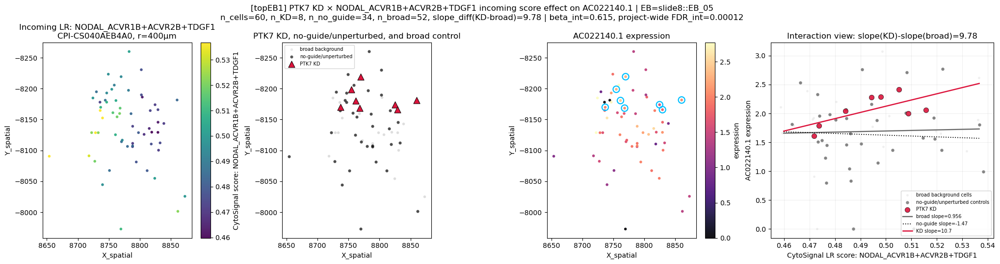

  plotting topEB2: EB=slide9::EB_07, slope_diff=-0.59
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r400um__slide9_EB_07_cells.csv


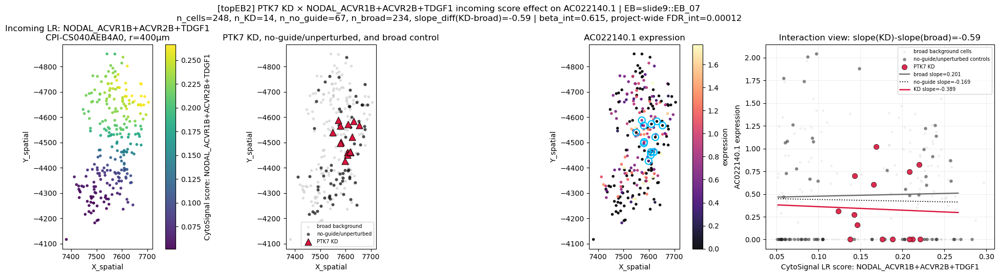


[8] interaction-aware EB selection for EPHA6 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_14,72,8,18,64,not_current_target_exclude_ambiguous,True,1.0,72,0.958333,69,0.007269,0.713619,1.0,8,1.0,8,1.0,64,0.953125,61,0.005166,0.014872,18.559855,-9.849377,28.409233,28.409233,0.117465,0.367867,0.485332,1.0,True,0.077747,-0.104183,0.181930,-0.175540,-0.284319,0.108779,True,1280.472270
1,slide5::EB_15,217,18,104,199,not_current_target_exclude_ambiguous,True,1.0,217,1.000000,217,0.040031,0.625656,1.0,18,1.0,18,1.0,199,1.000000,199,0.074035,0.098051,6.331377,-1.922321,8.253698,8.253698,0.117465,0.367867,0.485332,1.0,True,0.340407,-0.122327,0.462734,0.236176,-0.110850,0.347026,True,417.724468
2,slide8::EB_34,409,10,184,399,not_current_target_exclude_ambiguous,True,1.0,409,1.000000,409,0.038904,0.590982,1.0,10,1.0,10,1.0,399,1.000000,399,0.035098,0.087581,7.990930,1.995922,5.995008,5.995008,0.117465,0.367867,0.485332,1.0,True,0.306559,0.132215,0.174344,-0.002061,0.185008,-0.187068,False,403.685600
3,slide8::EB_74,177,8,89,169,not_current_target_exclude_ambiguous,True,1.0,177,1.000000,177,0.018678,0.560278,1.0,8,1.0,8,1.0,169,1.000000,169,0.041635,0.054297,7.261526,1.061139,6.200387,6.200387,0.117465,0.367867,0.485332,1.0,True,0.468276,0.034826,0.433450,0.415993,0.046023,0.369971,True,393.212724
4,slide8::EB_115,637,19,412,618,not_current_target_exclude_ambiguous,True,1.0,637,1.000000,637,0.033202,0.615785,1.0,19,1.0,19,1.0,618,1.000000,618,0.051085,0.085214,5.285380,-2.546651,7.832031,7.832031,0.117465,0.367867,0.485332,1.0,True,0.256166,-0.136583,0.392749,0.218077,-0.245635,0.463711,True,375.623612
5,slide8::EB_37,169,17,83,152,not_current_target_exclude_ambiguous,True,1.0,169,1.000000,169,0.042570,0.676621,1.0,17,1.0,17,1.0,152,1.000000,152,0.028844,0.110456,-5.995701,1.111000,-7.106701,-7.106701,0.117465,0.367867,0.485332,1.0,False,-0.195096,0.070745,-0.265841,0.024428,0.100517,-0.076089,False,362.925577
6,slide2::EB_47,300,11,177,289,not_current_target_exclude_ambiguous,True,1.0,300,1.000000,300,0.041435,0.613299,1.0,11,1.0,11,1.0,289,1.000000,289,0.057089,0.090850,-4.990442,1.109699,-6.100141,-6.100141,0.117465,0.367867,0.485332,1.0,False,-0.338438,0.075090,-0.413528,0.020397,0.073707,-0.053309,False,308.194111
7,slide8::EB_01,309,11,139,298,not_current_target_exclude_ambiguous,True,1.0,309,1.000000,309,0.066397,0.616843,1.0,11,1.0,11,1.0,298,1.000000,298,0.051757,0.126220,-5.291548,-0.751511,-4.540037,-4.540037,0.117465,0.367867,0.485332,1.0,False,-0.307058,-0.081263,-0.225794,-0.407811,-0.073944,-0.333867,False,278.734167
8,slide7::EB_34,2190,29,1012,2161,not_current_target_exclude_ambiguous,True,1.0,2190,1.000000,2190,0.047266,0.652838,1.0,29,1.0,29,1.0,2161,1.000000,2161,0.092706,0.126685,-3.565723,1.881910,-5.447633,-5.447633,0.117465,0.367867,0.485332,1.0,False,-0.230562,0.136189,-0.366752,-0.225516,0.184177,-0.409693,False,253.879354
9,slide8::EB_98,169,14,92,155,not_current_target_exclude_ambiguous,True,1.0,169,1.000000,169,0.036945,0.643459,1.0,14,1.0,14,1.0,155,1.000000,155,0.053024,0.082493,1.315004,-1.375203,2.690207,2.690207,0.117465,0.367867,0.485332,1.0,True,0.066200,-0.081303,0.147503,-0.126698,-0.150381,0.023683,True,121.582399


  plotting topEB1: EB=slide9::EB_14, slope_diff=28.4
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_14_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_14_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_14_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_14_cells.csv


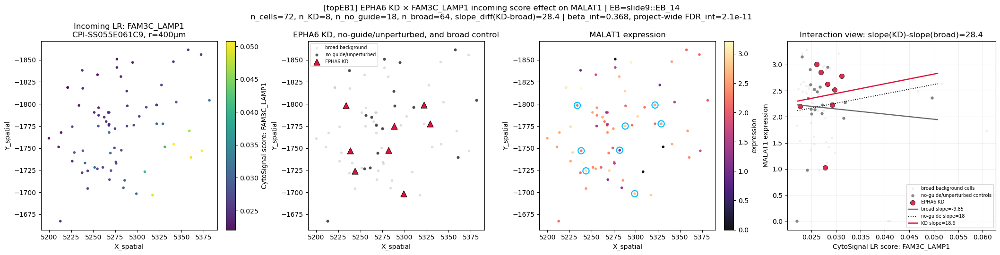

  plotting topEB2: EB=slide5::EB_15, slope_diff=8.25
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide5_EB_15_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide5_EB_15_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide5_EB_15_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide5_EB_15_cells.csv


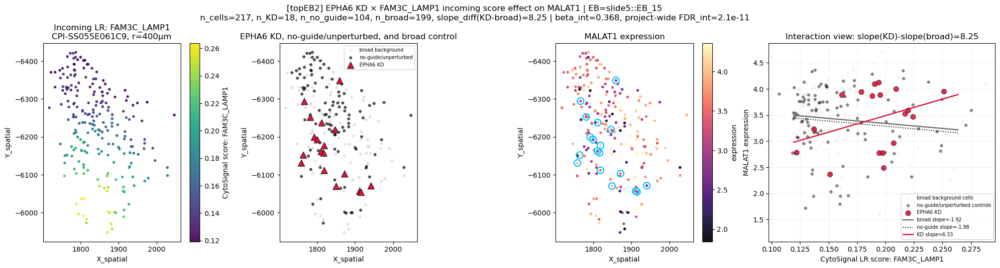

  plotting topEB3: EB=slide8::EB_34, slope_diff=6
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide8_EB_34_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide8_EB_34_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide8_EB_34_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS055E061C9__r400um__slide8_EB_34_cells.csv


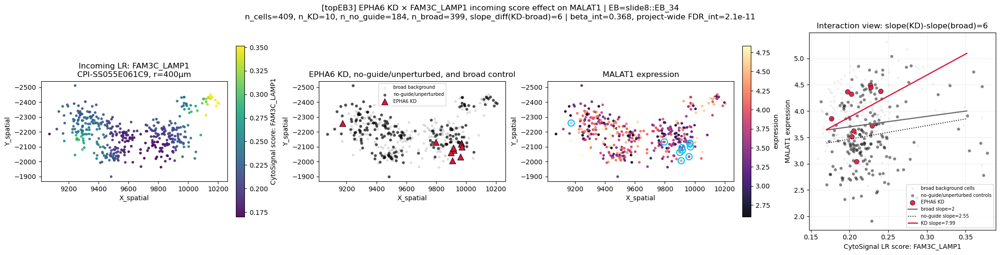


[9] interaction-aware EB selection for PDK3 KD × BDNF_F11R (CPI-SS03F0B666C) × GRID2, radius=400µm
  skipped: no EB passed interaction-aware filters

[10] interaction-aware EB selection for KALRN KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_07,248,10,67,238,not_current_target_exclude_ambiguous,True,1.0,248,0.959677,238,0.074722,0.760178,1.0,10,0.7,7,1.0,238,0.970588,231,0.017918,0.186854,97.055503,-3.098437,100.153940,100.153940,0.094131,0.485426,0.579556,1.0,True,0.685559,-0.312031,0.997591,2.426885,-0.502005,2.928890,True,5456.235342
1,slide7::EB_34,2190,16,1012,2174,not_current_target_exclude_ambiguous,True,1.0,2190,1.000000,2190,0.140954,0.652838,1.0,16,1.0,16,1.0,2174,1.000000,2174,0.135929,0.367074,0.912206,-0.552709,1.464915,1.464915,0.094131,0.485426,0.579556,1.0,True,0.097283,-0.119491,0.216773,0.562739,-0.170046,0.732785,True,84.495043
2,slide7::EB_17,2046,10,1057,2036,not_current_target_exclude_ambiguous,True,1.0,2046,0.999022,2044,0.112891,0.669474,1.0,10,1.0,10,1.0,2036,0.999018,2034,0.177455,0.284555,-0.668081,-0.822168,0.154087,0.154087,0.094131,0.485426,0.579556,1.0,True,-0.091523,-0.138666,0.047143,-0.103351,-0.215590,0.112240,True,38.604269
3,slide6::EB_12,2112,9,1405,2103,not_current_target_exclude_ambiguous,True,1.0,2112,1.000000,2112,0.105419,0.565691,1.0,9,1.0,9,1.0,2103,1.000000,2103,0.056118,0.260319,-0.451740,-0.889164,0.437424,0.437424,0.094131,0.485426,0.579556,1.0,True,-0.024757,-0.165998,0.141241,-0.174120,-0.224147,0.050027,True,38.299705


  plotting topEB1: EB=slide9::EB_07, slope_diff=100
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_07_cells.csv


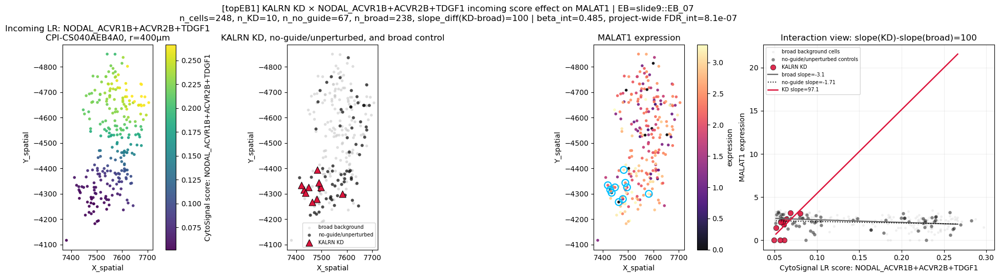

  plotting topEB2: EB=slide7::EB_34, slope_diff=1.46
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_34_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_34_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_34_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_34_cells.csv


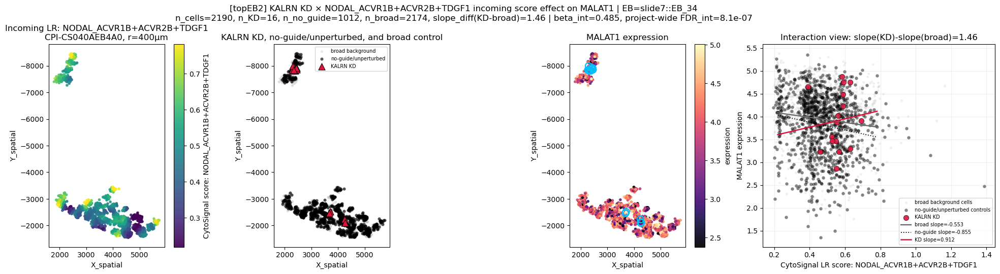

  plotting topEB3: EB=slide7::EB_17, slope_diff=0.154
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__KALRN__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_17_cells.csv


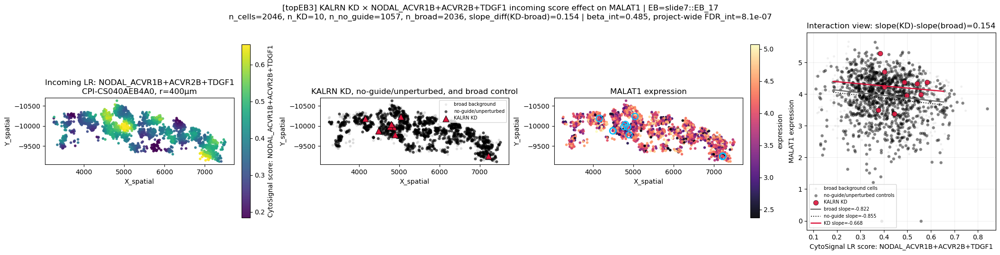


[11] interaction-aware EB selection for MAST3 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=200µm
  skipped: no EB passed interaction-aware filters

[12] interaction-aware EB selection for BMP2K KD × MDK_LRP1 (CPI-SS006C6537E) × NRIP1, radius=200µm
  skipped: no EB passed interaction-aware filters

[13] interaction-aware EB selection for MAST3 KD × FGF2_FGFR1 (CPI-SS01F67987A) × MALAT1, radius=200µm
  skipped: no EB passed interaction-aware filters

[14] interaction-aware EB selection for ILK KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=200µm
  skipped: no EB passed interaction-aware filters

[15] interaction-aware EB selection for PRKD3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × XACT, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide6::EB_12,2112,9,1405,2103,not_current_target_exclude_ambiguous,True,0.996686,2105,0.808239,1707,0.315565,0.818590,1.0,9,1.0,9,0.996671,2096,0.807418,1698,0.414937,0.814968,1.909721,-0.018628,1.928349,1.928349,0.080854,0.507093,0.587947,1.0,True,0.597024,-0.007194,0.604219,0.396183,-0.031138,0.427321,True,129.602652
1,slide8::EB_114,457,12,279,445,not_current_target_exclude_ambiguous,True,0.995624,455,0.824945,377,0.253872,0.865422,1.0,12,1.0,12,0.995506,443,0.820225,365,0.497758,0.654204,0.335365,0.000355,0.335010,0.335010,0.080854,0.507093,0.587947,1.0,True,0.155093,0.000102,0.154991,0.307172,-0.076233,0.383405,True,37.138513


  plotting topEB1: EB=slide6::EB_12, slope_diff=1.93


Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide6_EB_12_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide6_EB_12_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide6_EB_12_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide6_EB_12_cells.csv


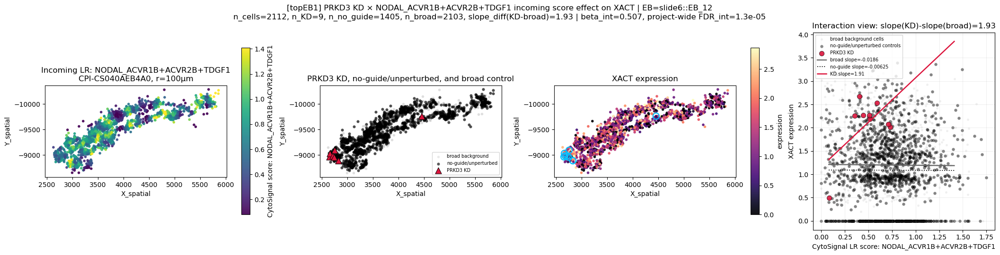

  plotting topEB2: EB=slide8::EB_114, slope_diff=0.335
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide8_EB_114_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide8_EB_114_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide8_EB_114_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r100um__slide8_EB_114_cells.csv


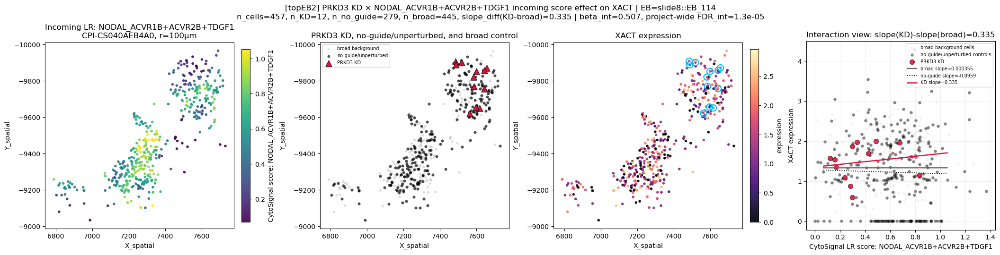


[16] interaction-aware EB selection for FLT4 KD × SEMA3A_NRP1+PLXNA2 (CPI-CS0D238C22B) × CDH18, radius=100µm
  skipped: no EB passed interaction-aware filters

[17] interaction-aware EB selection for MAPK6 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_39,57,9,17,48,not_current_target_exclude_ambiguous,True,1.0,57,0.982456,56,0.016631,0.600763,1.0,9,1.0,9,1.0,48,0.979167,47,0.037694,0.034058,-17.946501,1.450655,-19.397156,-19.397156,0.094134,0.414919,0.509053,1.0,False,-0.766592,0.038337,-0.804929,-0.646808,-0.064957,-0.581850,False,1036.353342
1,slide9::EB_50,87,16,31,71,not_current_target_exclude_ambiguous,True,1.0,87,0.965517,84,0.050333,0.713968,1.0,16,1.0,16,1.0,71,0.957746,68,0.104736,0.136998,-0.946091,-4.224251,3.278159,3.278159,0.094134,0.414919,0.509053,1.0,True,-0.095469,-0.265874,0.170405,-0.036437,-0.510016,0.473578,True,128.016192
2,slide8::EB_61,118,8,53,110,not_current_target_exclude_ambiguous,True,1.0,118,1.000000,118,0.057778,0.581302,1.0,8,1.0,8,1.0,110,1.000000,110,0.112810,0.150158,1.237515,-1.212120,2.449635,2.449635,0.094134,0.414919,0.509053,1.0,True,0.275619,-0.118624,0.394242,0.058825,-0.244122,0.302947,True,116.398396
3,slide6::EB_12,2112,11,1405,2101,not_current_target_exclude_ambiguous,True,1.0,2112,1.000000,2112,0.105419,0.565691,1.0,11,1.0,11,1.0,2101,1.000000,2101,0.166688,0.260674,-2.276534,-0.887131,-1.389403,-1.389403,0.094134,0.414919,0.509053,1.0,False,-0.212603,-0.166104,-0.046499,0.046442,-0.220995,0.267437,True,110.797911


  plotting topEB1: EB=slide9::EB_39, slope_diff=-19.4
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_cells.csv


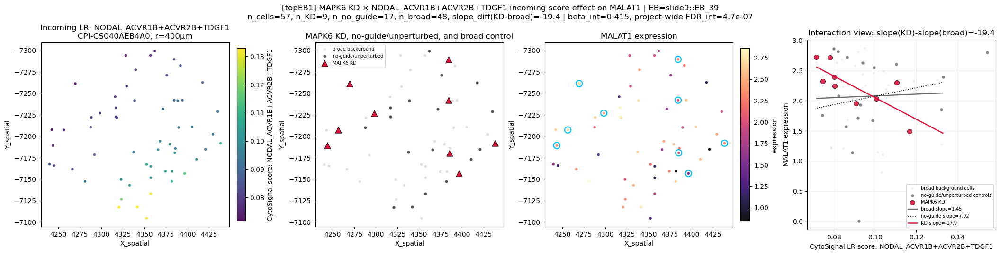

  plotting topEB2: EB=slide9::EB_50, slope_diff=3.28
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_50_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_50_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_50_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_50_cells.csv


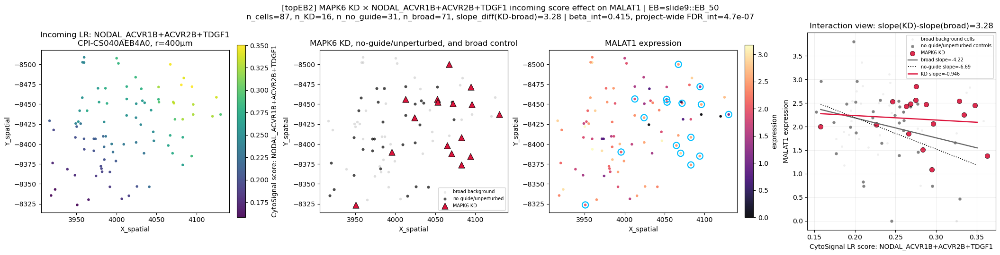

  plotting topEB3: EB=slide8::EB_61, slope_diff=2.45
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide8_EB_61_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide8_EB_61_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide8_EB_61_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-CS040AEB4A0__r400um__slide8_EB_61_cells.csv


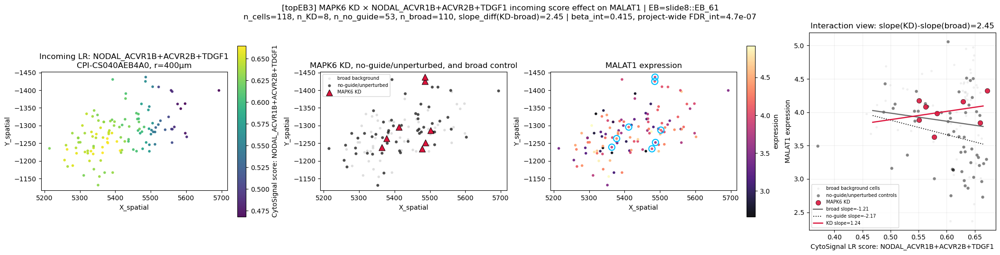


[18] interaction-aware EB selection for ROR1 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × FTX, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide5::EB_02,692,15,326,677,not_current_target_exclude_ambiguous,True,1.000000,692,0.828035,573,0.098233,0.648101,1.0,15,1.0,15,1.000000,677,0.824225,558,0.147306,0.245256,-1.290314,0.103066,-1.393379,-1.393379,0.040853,0.627933,0.668786,1.0,False,-0.224061,0.015597,-0.239658,-0.057102,0.030185,-0.087287,False,79.036955
1,slide6::EB_06,107,11,61,96,not_current_target_exclude_ambiguous,True,0.990654,106,0.897196,96,0.070235,0.618857,1.0,11,1.0,11,0.989583,95,0.885417,85,0.187185,0.161803,0.925908,0.761155,0.164753,0.164753,0.040853,0.627933,0.668786,1.0,True,0.286305,0.083375,0.202929,0.151526,-0.041391,0.192917,True,49.014373


  plotting topEB1: EB=slide5::EB_02, slope_diff=-1.39
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__FTX__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__FTX__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__FTX__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__FTX__CPI-SS055E061C9__r100um__slide5_EB_02_cells.csv


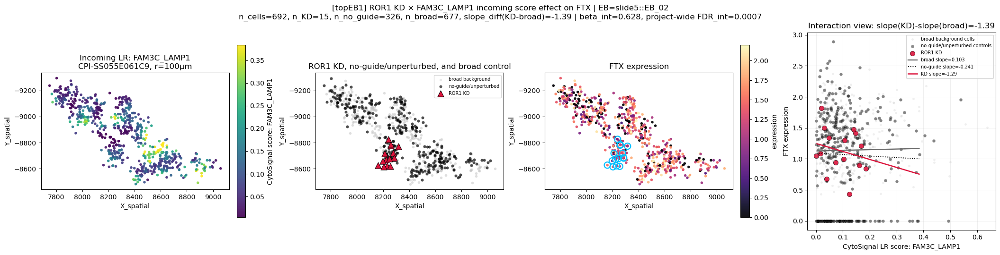

  plotting topEB2: EB=slide6::EB_06, slope_diff=0.165
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__FTX__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__FTX__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__FTX__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__FTX__CPI-SS055E061C9__r100um__slide6_EB_06_cells.csv


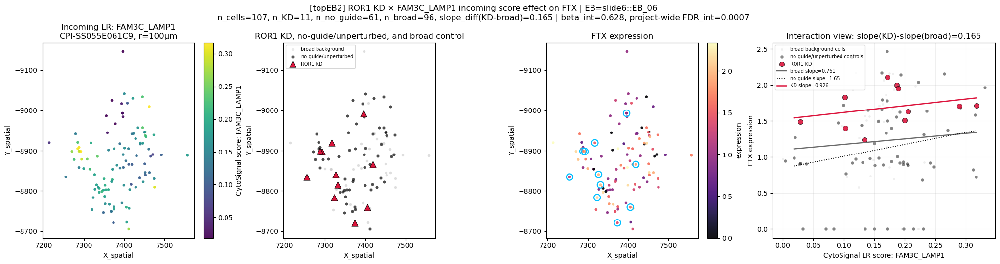


[19] interaction-aware EB selection for MYO3B KD × BMP7_PTPRK (CPI-SS0472C478C) × RMST, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide8::EB_01,309,14,139,295,not_current_target_exclude_ambiguous,True,0.980583,303,0.627832,194,0.310691,0.825162,1.0,14,0.928571,13,0.979661,289,0.613559,181,0.733545,0.683905,2.165789,0.039065,2.126724,2.126724,0.099343,0.408139,0.507483,1.0,True,0.710350,0.015571,0.694779,1.455887,0.007745,1.448142,True,151.267332
1,slide7::EB_17,2046,13,1057,2033,not_current_target_exclude_ambiguous,True,0.994135,2034,0.520528,1065,0.319550,0.801568,1.0,13,0.923077,12,0.994097,2021,0.517954,1053,0.815430,0.785368,1.506107,0.120597,1.385510,1.385510,0.099343,0.408139,0.507483,1.0,True,0.579052,0.048377,0.530675,1.200408,0.070217,1.130190,True,109.207789
2,slide5::EB_02,692,12,326,680,not_current_target_exclude_ambiguous,True,1.000000,692,0.482659,334,0.282705,0.637575,1.0,12,0.416667,5,1.000000,680,0.483824,329,0.328963,0.734501,1.068226,0.140046,0.928180,0.928180,0.099343,0.408139,0.507483,1.0,True,0.223200,0.061730,0.161470,-0.085732,0.076194,-0.161926,False,69.924594


  plotting topEB1: EB=slide8::EB_01, slope_diff=2.13
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MYO3B__RMST__CPI-SS0472C478C__r100um__slide8_EB_01_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MYO3B__RMST__CPI-SS0472C478C__r100um__slide8_EB_01_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MYO3B__RMST__CPI-SS0472C478C__r100um__slide8_EB_01_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MYO3B__RMST__CPI-SS0472C478C__r100um__slide8_EB_01_cells.csv


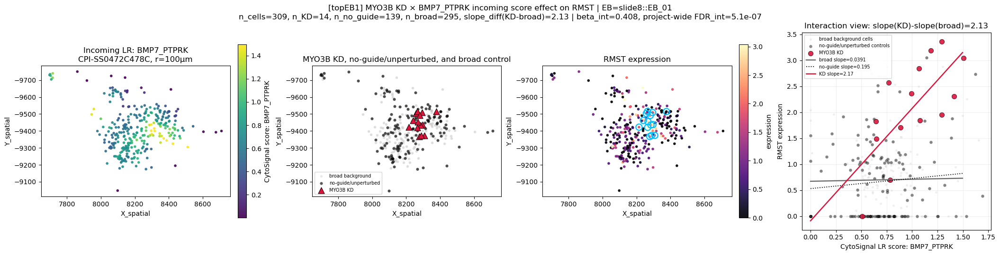

  plotting topEB2: EB=slide7::EB_17, slope_diff=1.39
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MYO3B__RMST__CPI-SS0472C478C__r100um__slide7_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MYO3B__RMST__CPI-SS0472C478C__r100um__slide7_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MYO3B__RMST__CPI-SS0472C478C__r100um__slide7_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MYO3B__RMST__CPI-SS0472C478C__r100um__slide7_EB_17_cells.csv


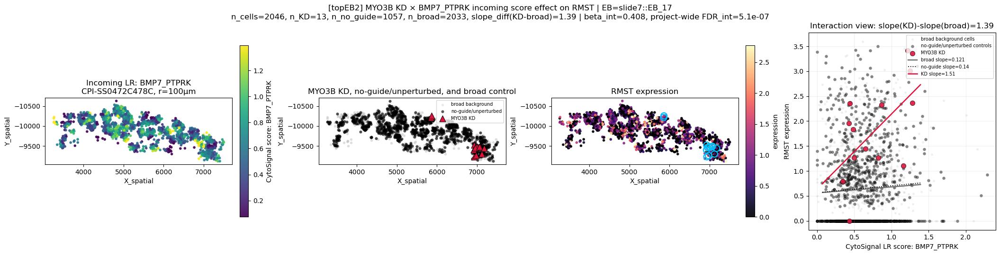

  plotting topEB3: EB=slide5::EB_02, slope_diff=0.928
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MYO3B__RMST__CPI-SS0472C478C__r100um__slide5_EB_02_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MYO3B__RMST__CPI-SS0472C478C__r100um__slide5_EB_02_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MYO3B__RMST__CPI-SS0472C478C__r100um__slide5_EB_02_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MYO3B__RMST__CPI-SS0472C478C__r100um__slide5_EB_02_cells.csv


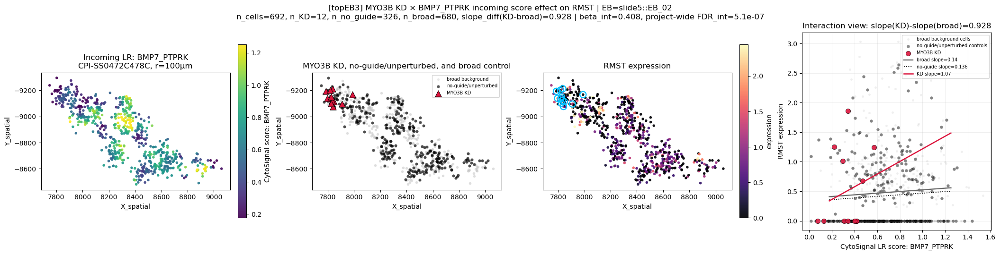


[20] interaction-aware EB selection for NIM1K KD × BMP4_BMPR1B+ACVR2B (CPI-CS0E997FABD) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_06,520,11,196,509,not_current_target_exclude_ambiguous,True,1.0,520,0.982692,511,0.030386,0.675754,1.0,11,1.0,11,1.0,509,0.982318,500,0.026023,0.071137,8.870922,2.925047,5.945876,5.945876,0.163586,0.39222,0.555806,1.0,True,0.186524,0.132412,0.054113,0.367137,0.208065,0.159073,True,430.29716
1,slide7::EB_54,211,8,98,203,not_current_target_exclude_ambiguous,True,1.0,211,1.000000,211,0.025239,0.593500,1.0,8,1.0,8,1.0,203,1.000000,203,0.026212,0.063509,0.309314,4.801895,-4.492581,-4.492581,0.163586,0.39222,0.555806,1.0,False,0.016283,0.196935,-0.180651,0.104388,0.301738,-0.197350,False,124.01162


  plotting topEB1: EB=slide9::EB_06, slope_diff=5.95
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide9_EB_06_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide9_EB_06_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide9_EB_06_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide9_EB_06_cells.csv


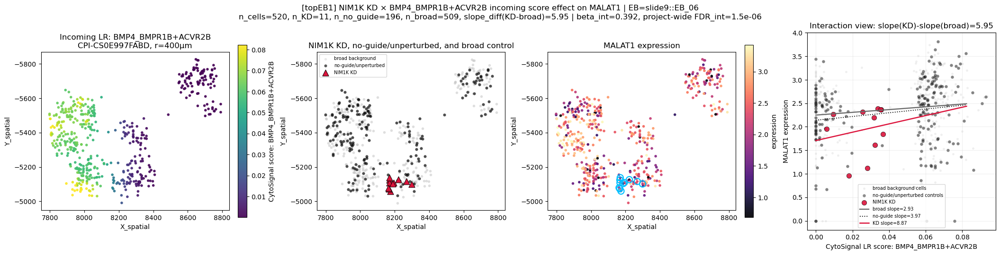

  plotting topEB2: EB=slide7::EB_54, slope_diff=-4.49
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide7_EB_54_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide7_EB_54_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide7_EB_54_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NIM1K__MALAT1__CPI-CS0E997FABD__r400um__slide7_EB_54_cells.csv


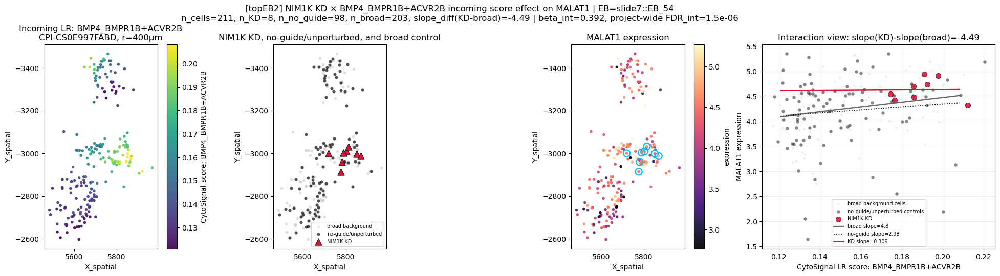


[21] interaction-aware EB selection for NEK1 KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide8::EB_98,169,12,92,157,not_current_target_exclude_ambiguous,True,1.0,169,1.000000,169,0.060116,0.643459,1.0,12,1.0,12,1.0,157,1.000000,157,0.039223,0.150450,21.405387,-0.502988,21.908375,21.908375,0.118467,0.358835,0.477302,1.0,True,0.398502,-0.048777,0.447280,0.799652,0.048352,0.751300,True,1212.894484
1,slide5::EB_14,360,8,176,352,not_current_target_exclude_ambiguous,True,1.0,360,0.991667,357,0.040432,0.670078,1.0,8,1.0,8,1.0,352,0.991477,349,0.069402,0.103915,-6.210114,2.739419,-8.949533,-8.949533,0.118467,0.358835,0.477302,1.0,False,-0.655836,0.164025,-0.819861,-0.226963,0.262436,-0.489399,False,422.640862
2,slide7::EB_65,353,8,146,345,not_current_target_exclude_ambiguous,True,1.0,353,1.000000,353,0.076784,0.646472,1.0,8,1.0,8,1.0,345,1.000000,345,0.117996,0.195544,-6.500220,0.209651,-6.709871,-6.709871,0.118467,0.358835,0.477302,1.0,False,-0.824304,0.024965,-0.849270,-0.512196,0.026683,-0.538879,False,377.310089
3,slide6::EB_12,2112,8,1405,2104,not_current_target_exclude_ambiguous,True,1.0,2112,1.000000,2112,0.076939,0.565691,1.0,8,1.0,8,1.0,2104,1.000000,2104,0.137029,0.210795,3.942309,-0.215599,4.157907,4.157907,0.118467,0.358835,0.477302,1.0,True,0.597321,-0.029294,0.626614,0.420115,-0.031295,0.451410,True,245.369202
4,slide8::EB_99,436,8,269,428,not_current_target_exclude_ambiguous,True,1.0,436,1.000000,436,0.048636,0.747829,1.0,8,1.0,8,1.0,428,1.000000,428,0.108365,0.114009,3.924092,0.870098,3.053994,3.053994,0.118467,0.358835,0.477302,1.0,True,0.562236,0.056218,0.506018,0.402429,0.124049,0.278380,True,215.173098
5,slide8::EB_37,169,8,83,161,not_current_target_exclude_ambiguous,True,1.0,169,1.000000,169,0.046894,0.676621,1.0,8,1.0,8,1.0,161,1.000000,161,0.115075,0.127680,2.257885,1.909316,0.348570,0.348570,0.118467,0.358835,0.477302,1.0,True,0.505201,0.125927,0.379274,0.180581,0.210135,-0.029554,False,91.992019
6,slide7::EB_34,2190,10,1012,2180,not_current_target_exclude_ambiguous,True,1.0,2190,1.000000,2190,0.077644,0.652838,1.0,10,1.0,10,1.0,2180,1.000000,2180,0.444491,0.191721,-1.008480,-0.130350,-0.878130,-0.878130,0.118467,0.358835,0.477302,1.0,False,-0.449842,-0.015240,-0.434602,-0.326922,-0.014849,-0.312073,False,61.384599


  plotting topEB1: EB=slide8::EB_98, slope_diff=21.9
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_98_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_98_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_98_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_98_cells.csv


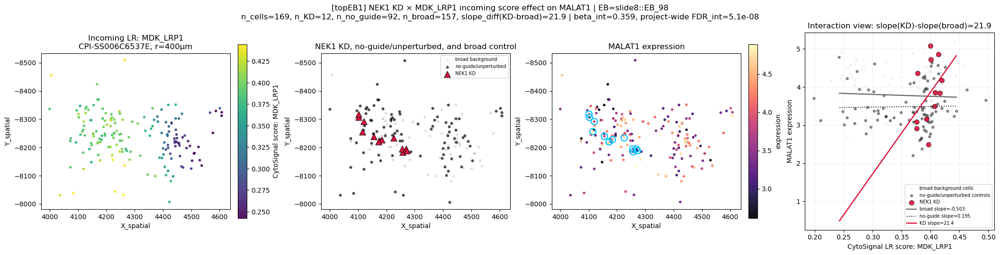

  plotting topEB2: EB=slide5::EB_14, slope_diff=-8.95
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_14_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_14_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_14_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_14_cells.csv


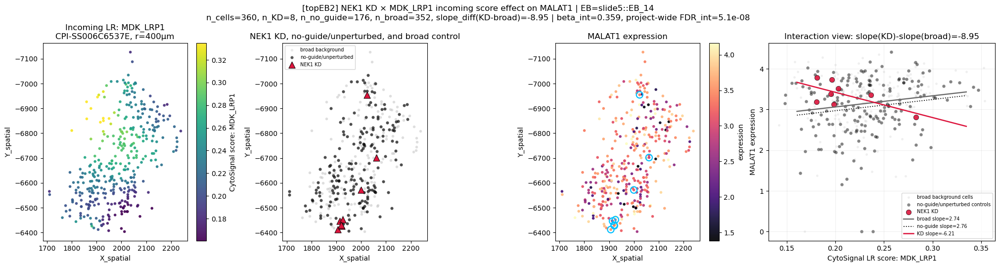

  plotting topEB3: EB=slide7::EB_65, slope_diff=-6.71
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide7_EB_65_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide7_EB_65_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide7_EB_65_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__NEK1__MALAT1__CPI-SS006C6537E__r400um__slide7_EB_65_cells.csv


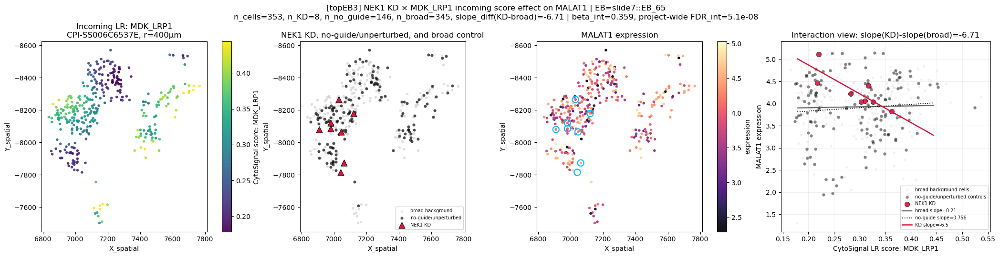


[22] interaction-aware EB selection for PRKD3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × XACT, radius=200µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide6::EB_12,2112,9,1405,2103,not_current_target_exclude_ambiguous,True,1.0,2112,0.808239,1707,0.209429,0.818590,1.0,9,1.0,9,1.0,2103,0.807418,1698,0.194054,0.532045,3.953655,-0.033739,3.987394,3.987394,0.095045,0.450189,0.545234,1.0,True,0.759587,-0.008643,0.768230,0.277988,-0.030503,0.308491,True,243.150417
1,slide8::EB_114,457,12,279,445,not_current_target_exclude_ambiguous,True,1.0,457,0.824945,377,0.163403,0.865422,1.0,12,1.0,12,1.0,445,0.820225,365,0.386747,0.423492,0.412940,0.002566,0.410374,0.410374,0.095045,0.450189,0.545234,1.0,True,0.136073,0.000472,0.135601,0.028797,-0.003649,0.032446,True,38.599923


  plotting topEB1: EB=slide6::EB_12, slope_diff=3.99
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide6_EB_12_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide6_EB_12_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide6_EB_12_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide6_EB_12_cells.csv


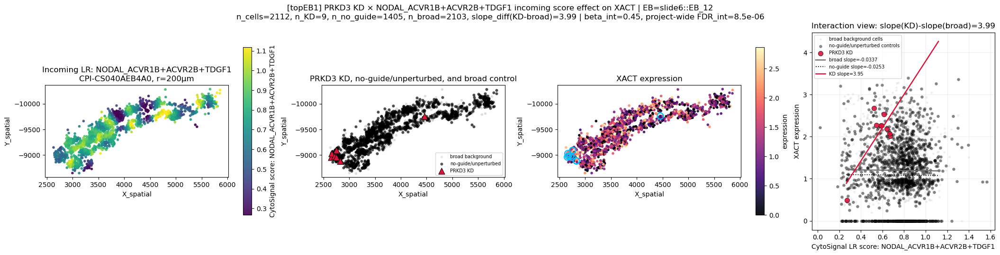

  plotting topEB2: EB=slide8::EB_114, slope_diff=0.41
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide8_EB_114_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide8_EB_114_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide8_EB_114_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKD3__XACT__CPI-CS040AEB4A0__r200um__slide8_EB_114_cells.csv


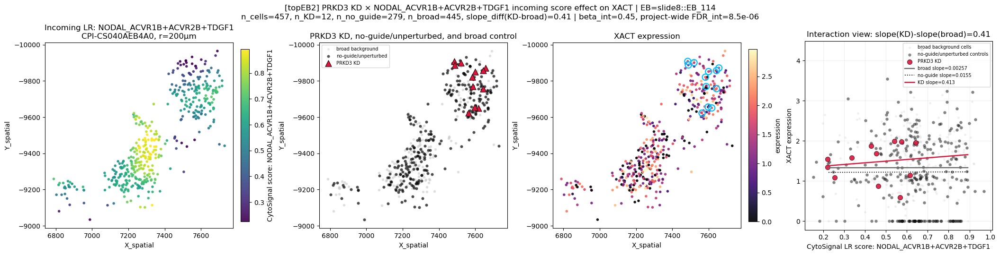


[23] interaction-aware EB selection for BMP2K KD × MDK_LRP1 (CPI-SS006C6537E) × NRIP1, radius=100µm
  skipped: no EB passed interaction-aware filters

[24] interaction-aware EB selection for ILK KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=100µm
  skipped: no EB passed interaction-aware filters

[25] interaction-aware EB selection for CSK KD × WNT5A_FZD3 (CPI-SS002673EFE) × GRID2, radius=200µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_22,195,14,80,181,not_current_target_exclude_ambiguous,True,0.764103,149,0.646154,126,0.010572,0.766638,1.0,14,0.785714,11,0.745856,135,0.635359,115,0.032908,0.011582,-7.815958,8.540869,-16.356827,-16.356827,0.079339,0.855639,0.934979,1.0,False,-0.165885,0.108397,-0.274282,-0.334076,-0.10803,-0.226046,False,648.828675


  plotting topEB1: EB=slide9::EB_22, slope_diff=-16.4
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CSK__GRID2__CPI-SS002673EFE__r200um__slide9_EB_22_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CSK__GRID2__CPI-SS002673EFE__r200um__slide9_EB_22_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CSK__GRID2__CPI-SS002673EFE__r200um__slide9_EB_22_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CSK__GRID2__CPI-SS002673EFE__r200um__slide9_EB_22_cells.csv


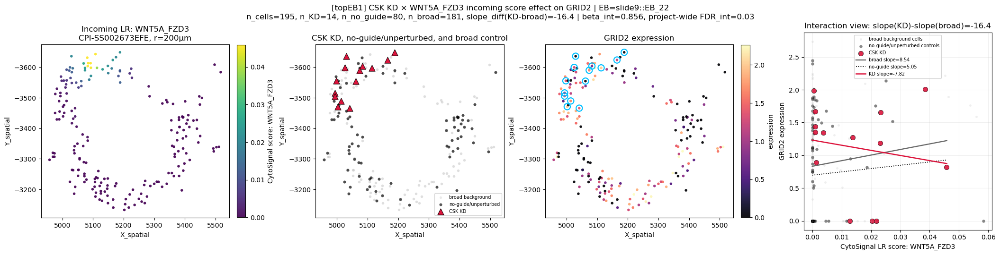


[26] interaction-aware EB selection for PRKAA1 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_40,91,30,13,61,not_current_target_exclude_ambiguous,True,1.0,91,0.967033,88,0.007979,0.754628,1.0,30,0.966667,29,1.0,61,0.967213,59,0.022851,0.016803,29.383385,-13.399076,42.782462,42.782462,0.094166,0.404155,0.498322,1.0,True,0.377666,-0.123614,0.501280,0.769297,-0.098764,0.868060,True,1977.467496
1,slide7::EB_51,705,13,301,692,not_current_target_exclude_ambiguous,True,1.0,705,0.998582,704,0.164550,0.667674,1.0,13,1.000000,13,1.0,692,0.998555,691,0.059749,0.354521,-6.476251,-0.474056,-6.002195,-6.002195,0.094166,0.404155,0.498322,1.0,False,-0.186461,-0.118411,-0.068050,-0.132507,-0.074617,-0.057890,False,348.007076
2,slide9::EB_09,175,11,107,164,not_current_target_exclude_ambiguous,True,1.0,175,0.988571,173,0.020648,0.645406,1.0,11,1.000000,11,1.0,164,0.987805,162,0.063634,0.054916,5.679705,4.045741,1.633964,1.633964,0.094166,0.404155,0.498322,1.0,True,0.333848,0.126340,0.207508,0.339187,0.221499,0.117688,True,228.523139


  plotting topEB1: EB=slide9::EB_40, slope_diff=42.8
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_40_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_40_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_40_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_40_cells.csv


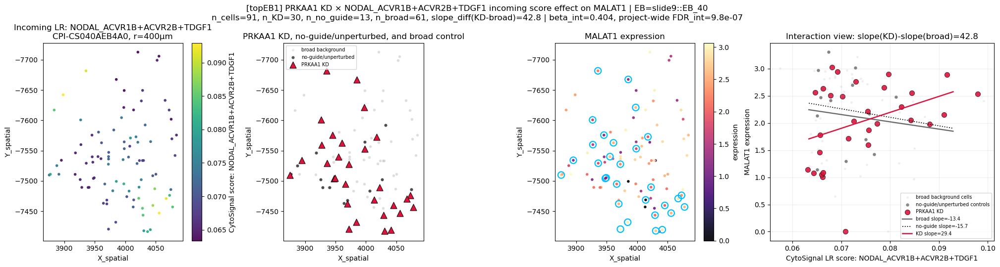

  plotting topEB2: EB=slide7::EB_51, slope_diff=-6
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_51_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_51_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_51_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide7_EB_51_cells.csv


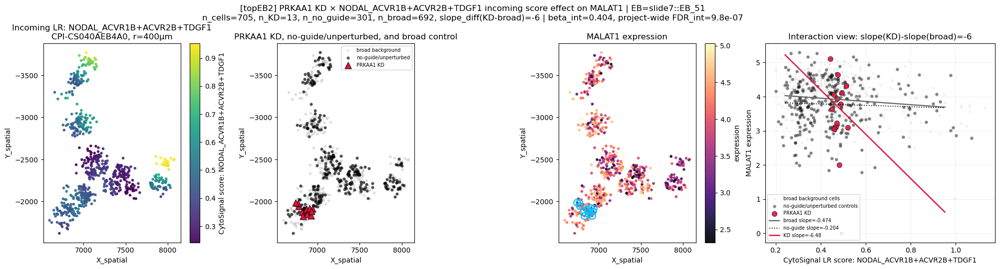

  plotting topEB3: EB=slide9::EB_09, slope_diff=1.63
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_09_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_09_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_09_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_09_cells.csv


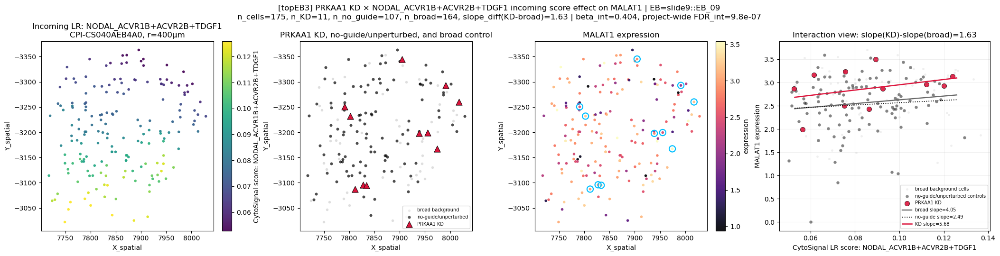


[27] interaction-aware EB selection for EPHA6 KD × SEMA3A_NRP1+PLXNA2 (CPI-CS0D238C22B) × LINC00378, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide5::EB_15,217,18,104,199,not_current_target_exclude_ambiguous,True,1.0,217,0.142857,31,0.054417,0.549552,1.0,18,0.166667,3,1.0,199,0.140704,28,0.124110,0.137604,11.872183,2.022857,9.849327,9.849327,0.058559,0.162612,0.221172,1.0,True,0.690068,0.212820,0.477249,1.087438,0.324485,0.762953,True,629.334600
1,slide7::EB_34,2190,29,1012,2161,not_current_target_exclude_ambiguous,True,1.0,2190,0.130137,285,0.175920,0.424014,1.0,29,0.137931,4,1.0,2161,0.130032,281,0.269756,0.457007,1.124598,0.781989,0.342608,0.342608,0.058559,0.162612,0.221172,1.0,True,0.406827,0.324730,0.082097,0.213350,0.231035,-0.017685,False,60.256607
2,slide7::EB_17,2046,22,1057,2024,not_current_target_exclude_ambiguous,True,1.0,2046,0.125122,256,0.164454,0.421678,1.0,22,0.409091,9,1.0,2024,0.122036,247,0.395622,0.360403,0.791083,0.562030,0.229053,0.229053,0.058559,0.162612,0.221172,1.0,True,0.320129,0.218420,0.101709,0.611698,0.198046,0.413652,True,50.971861
3,slide8::EB_01,309,11,139,298,not_current_target_exclude_ambiguous,True,1.0,309,0.181230,56,0.166589,0.526379,1.0,11,0.909091,10,1.0,298,0.154362,46,0.154532,0.390676,0.292728,1.058928,-0.766200,-0.766200,0.058559,0.162612,0.221172,1.0,False,0.034247,0.362263,-0.328016,-0.268206,0.316296,-0.584501,False,34.659967


  plotting topEB1: EB=slide5::EB_15, slope_diff=9.85
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide5_EB_15_cells.csv


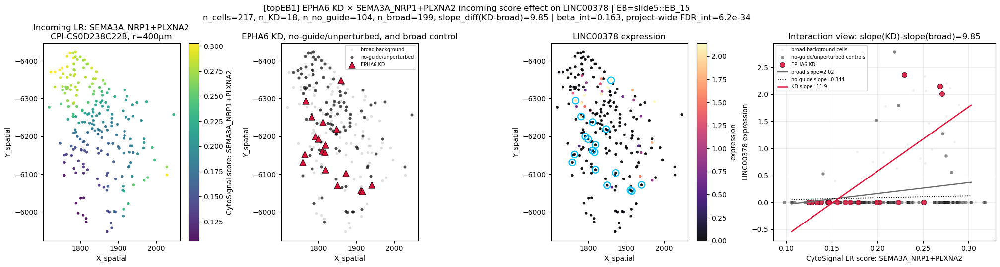

  plotting topEB2: EB=slide7::EB_34, slope_diff=0.343
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_34_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_34_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_34_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_34_cells.csv


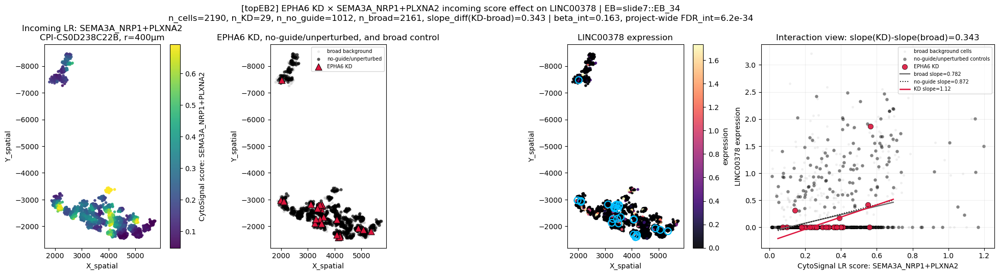

  plotting topEB3: EB=slide7::EB_17, slope_diff=0.229
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__LINC00378__CPI-CS0D238C22B__r400um__slide7_EB_17_cells.csv


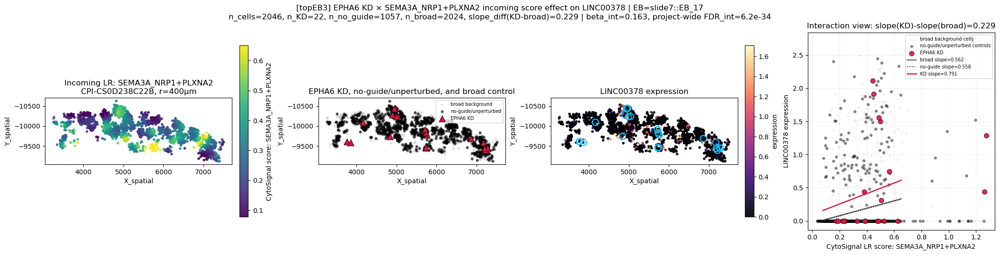


[28] interaction-aware EB selection for EPHA6 KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide5::EB_15,217,18,104,199,not_current_target_exclude_ambiguous,True,1.0,217,1.000000,217,0.023072,0.625656,1.0,18,1.0,18,1.0,199,1.000000,199,0.038060,0.055114,-13.154132,4.137219,-17.291350,-17.291350,0.118334,0.317342,0.435676,1.0,False,-0.358127,0.154234,-0.512362,-0.230766,0.290987,-0.521753,False,837.682508
1,slide9::EB_14,72,8,18,64,not_current_target_exclude_ambiguous,True,1.0,72,0.958333,69,0.015001,0.713619,1.0,8,1.0,8,1.0,64,0.953125,61,0.021692,0.018889,7.811380,-6.604916,14.416296,14.416296,0.118334,0.317342,0.435676,1.0,True,0.230039,-0.133562,0.363601,-0.319536,-0.304109,-0.015427,False,606.797228
2,slide8::EB_74,177,8,89,169,not_current_target_exclude_ambiguous,True,1.0,177,1.000000,177,0.062683,0.560278,1.0,8,1.0,8,1.0,169,1.000000,169,0.042231,0.164315,-6.808452,1.453430,-8.261881,-8.261881,0.118334,0.317342,0.435676,1.0,False,-0.468114,0.164593,-0.632707,-0.278487,0.228368,-0.506856,False,421.057860
3,slide8::EB_115,637,19,412,618,not_current_target_exclude_ambiguous,True,1.0,637,1.000000,637,0.038897,0.615785,1.0,19,1.0,19,1.0,618,1.000000,618,0.080973,0.088596,-4.176649,1.403368,-5.580017,-5.580017,0.118334,0.317342,0.435676,1.0,False,-0.358434,0.085504,-0.443938,-0.257315,0.170061,-0.427376,False,274.979721
4,slide6::EB_17,963,12,584,951,not_current_target_exclude_ambiguous,True,1.0,963,1.000000,963,0.058110,0.554118,1.0,12,1.0,12,1.0,951,1.000000,951,0.107090,0.152191,-4.556237,-0.098805,-4.457432,-4.457432,0.118334,0.317342,0.435676,1.0,False,-0.457678,-0.010432,-0.447247,-0.408112,-0.031188,-0.376924,False,257.510447
5,slide8::EB_01,309,11,139,298,not_current_target_exclude_ambiguous,True,1.0,309,1.000000,309,0.031386,0.616843,1.0,11,1.0,11,1.0,298,1.000000,298,0.021103,0.054140,-3.603541,0.352732,-3.956272,-3.956272,0.118334,0.317342,0.435676,1.0,False,-0.125082,0.018020,-0.143102,0.132099,0.161495,-0.029396,False,209.688387
6,slide2::EB_47,300,11,177,289,not_current_target_exclude_ambiguous,True,1.0,300,1.000000,300,0.044942,0.613299,1.0,11,1.0,11,1.0,289,1.000000,289,0.078835,0.108900,3.745677,0.570363,3.175313,3.175313,0.118334,0.317342,0.435676,1.0,True,0.290896,0.042399,0.248497,0.166248,0.070084,0.096165,True,208.839118
7,slide8::EB_98,169,14,92,155,not_current_target_exclude_ambiguous,True,1.0,169,1.000000,169,0.060116,0.643459,1.0,14,1.0,14,1.0,155,1.000000,155,0.120074,0.147149,3.337700,0.109798,3.227903,3.227903,0.118334,0.317342,0.435676,1.0,True,0.323929,0.010140,0.313789,0.455580,0.224120,0.231461,True,200.028223
8,slide8::EB_34,409,10,184,399,not_current_target_exclude_ambiguous,True,1.0,409,1.000000,409,0.070283,0.590982,1.0,10,1.0,10,1.0,399,1.000000,399,0.043505,0.153365,2.819072,-0.144879,2.963951,2.963951,0.118334,0.317342,0.435676,1.0,True,0.372280,-0.017105,0.389385,0.584335,0.124915,0.459421,True,179.054670
9,slide7::EB_34,2190,29,1012,2161,not_current_target_exclude_ambiguous,True,1.0,2190,1.000000,2190,0.077644,0.652838,1.0,29,1.0,29,1.0,2161,1.000000,2161,0.130821,0.194411,2.247820,-0.123090,2.370910,2.370910,0.118334,0.317342,0.435676,1.0,True,0.206622,-0.014662,0.221284,0.254258,-0.020904,0.275162,True,147.825172


  plotting topEB1: EB=slide5::EB_15, slope_diff=-17.3
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_15_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_15_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_15_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide5_EB_15_cells.csv


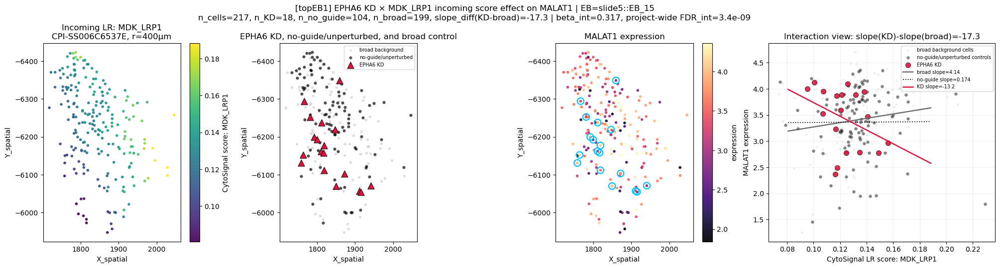

  plotting topEB2: EB=slide9::EB_14, slope_diff=14.4
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_14_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_14_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_14_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_14_cells.csv


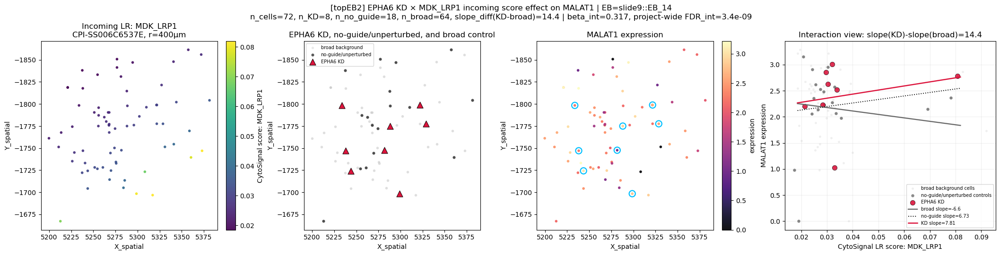

  plotting topEB3: EB=slide8::EB_74, slope_diff=-8.26
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_74_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_74_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_74_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__MALAT1__CPI-SS006C6537E__r400um__slide8_EB_74_cells.csv


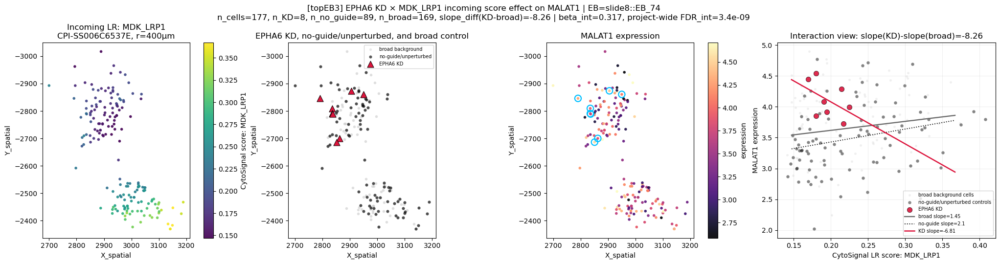


[29] interaction-aware EB selection for TEC KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_39,57,12,17,45,not_current_target_exclude_ambiguous,True,1.0,57,0.982456,56,0.016631,0.600763,1.0,12,1.0,12,1.0,45,0.977778,44,0.024130,0.037889,-21.952516,0.856550,-22.809066,-22.809066,0.094129,0.401328,0.495457,1.0,False,-0.452346,0.024881,-0.477227,-0.582424,-0.113810,-0.468615,False,1237.545401
1,slide2::EB_77,330,8,212,322,not_current_target_exclude_ambiguous,True,1.0,330,1.000000,330,0.076367,0.633167,1.0,8,1.0,8,1.0,322,1.000000,322,0.040908,0.138588,-22.324763,-1.050575,-21.274188,-21.274188,0.094129,0.401328,0.495457,1.0,False,-0.535252,-0.128878,-0.406374,-1.049762,-0.207502,-0.842260,False,1213.250790
2,slide5::EB_12,212,8,111,204,not_current_target_exclude_ambiguous,True,1.0,212,0.995283,211,0.026605,0.655325,1.0,8,1.0,8,1.0,204,0.995098,203,0.040746,0.064168,-10.564341,-3.063397,-7.500944,-7.500944,0.094129,0.401328,0.495457,1.0,False,-0.562217,-0.123996,-0.438221,-0.569470,-0.201641,-0.367829,False,513.579258
3,slide7::EB_65,353,9,146,344,not_current_target_exclude_ambiguous,True,1.0,353,1.000000,353,0.078251,0.646472,1.0,9,1.0,9,1.0,344,1.000000,344,0.039872,0.182193,8.212817,-1.074507,9.287324,9.287324,0.094129,0.401328,0.495457,1.0,True,0.242120,-0.130616,0.372736,-0.294983,-0.139110,-0.155874,False,492.819875
4,slide9::EB_45,167,11,97,156,not_current_target_exclude_ambiguous,True,1.0,167,0.976048,163,0.063230,0.741919,1.0,11,1.0,11,1.0,156,0.974359,152,0.059518,0.151999,-2.708060,-0.928556,-1.779505,-1.779505,0.094129,0.401328,0.495457,1.0,False,-0.157020,-0.079163,-0.077857,-0.185657,-0.204983,0.019326,True,131.423869
5,slide7::EB_17,2046,15,1057,2031,not_current_target_exclude_ambiguous,True,1.0,2046,0.999022,2044,0.112891,0.669474,1.0,15,1.0,15,1.0,2031,0.999015,2029,0.214332,0.284538,-1.695888,-0.814756,-0.881133,-0.881133,0.094129,0.401328,0.495457,1.0,False,-0.282312,-0.137218,-0.145094,-0.339805,-0.211261,-0.128543,False,78.802262


  plotting topEB1: EB=slide9::EB_39, slope_diff=-22.8
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide9_EB_39_cells.csv


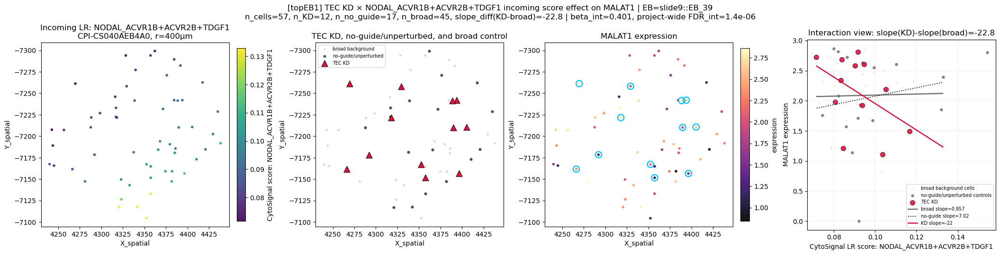

  plotting topEB2: EB=slide2::EB_77, slope_diff=-21.3
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide2_EB_77_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide2_EB_77_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide2_EB_77_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide2_EB_77_cells.csv


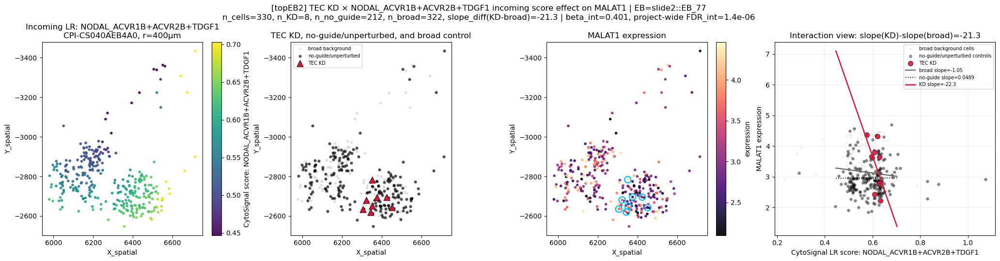

  plotting topEB3: EB=slide5::EB_12, slope_diff=-7.5
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide5_EB_12_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide5_EB_12_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide5_EB_12_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__TEC__MALAT1__CPI-CS040AEB4A0__r400um__slide5_EB_12_cells.csv


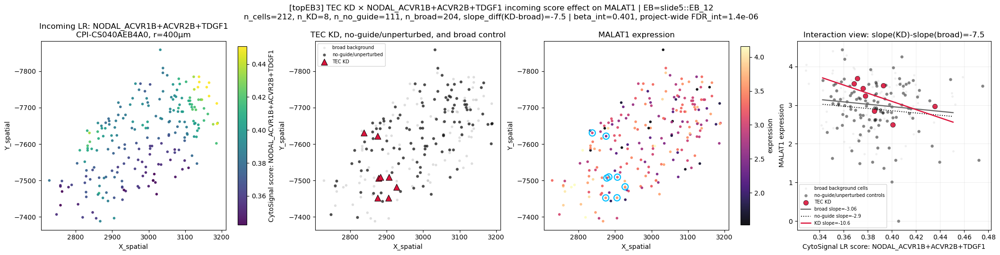


[30] interaction-aware EB selection for STK25 KD × MIF_CD74 (CPI-SS0ABC5C1B8) × ARHGAP24, radius=100µm
  skipped: no EB passed interaction-aware filters

[31] interaction-aware EB selection for PDK3 KD × BDNF_SORT1 (CPI-SS09A36B221) × GRID2, radius=400µm
  skipped: no EB passed interaction-aware filters

[32] interaction-aware EB selection for MAST3 KD × FGF2_FGFR1 (CPI-SS01F67987A) × MALAT1, radius=100µm
  skipped: no EB passed interaction-aware filters

[33] interaction-aware EB selection for PTK7 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × AC022140.1, radius=200µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide8::EB_05,60,8,34,52,not_current_target_exclude_ambiguous,True,1.0,60,0.950000,57,0.083701,0.625251,1.0,8,1.000000,8,1.0,52,0.942308,49,0.120027,0.202032,3.694044,-1.284686,4.978731,4.978731,0.180809,0.566562,0.747371,1.0,True,0.708446,-0.173202,0.881648,0.345250,-0.098417,0.443667,True,259.538983
1,slide9::EB_07,248,14,67,234,not_current_target_exclude_ambiguous,True,1.0,248,0.540323,134,0.110579,0.536066,1.0,14,0.571429,8,1.0,234,0.538462,126,0.128228,0.262284,0.504635,0.012973,0.491662,0.491662,0.180809,0.566562,0.747371,1.0,True,0.076995,0.002698,0.074297,0.023522,0.040893,-0.017372,False,39.275458


  plotting topEB1: EB=slide8::EB_05, slope_diff=4.98
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide8_EB_05_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide8_EB_05_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide8_EB_05_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide8_EB_05_cells.csv


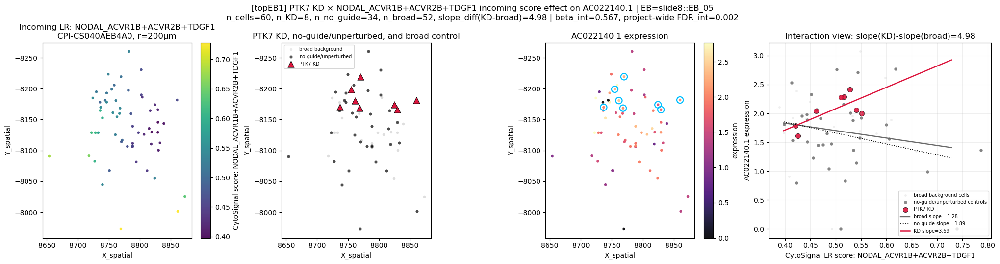

  plotting topEB2: EB=slide9::EB_07, slope_diff=0.492
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__AC022140.1__CPI-CS040AEB4A0__r200um__slide9_EB_07_cells.csv


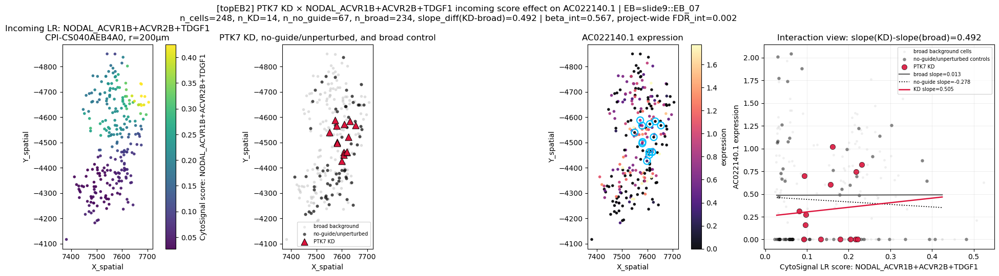


[34] interaction-aware EB selection for BMP2K KD × MDK_LRP1 (CPI-SS006C6537E) × SOX5, radius=100µm
  skipped: no EB passed interaction-aware filters

[35] interaction-aware EB selection for PDK3 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × GRID2, radius=200µm
  skipped: no EB passed interaction-aware filters

[36] interaction-aware EB selection for PRKAA1 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_09,175,11,107,164,not_current_target_exclude_ambiguous,True,1.0,175,0.988571,173,0.001384,0.645406,1.0,11,1.000000,11,1.0,164,0.987805,162,0.002499,0.003564,208.340020,71.015786,137.324234,137.324234,0.117698,0.417318,0.535015,1.0,True,0.506029,0.152242,0.353786,0.445904,0.254179,0.191726,True,9702.981626
1,slide7::EB_51,705,13,301,692,not_current_target_exclude_ambiguous,True,1.0,705,0.998582,704,0.069632,0.667674,1.0,13,1.000000,13,1.0,692,0.998555,691,0.048239,0.170862,9.497291,0.799777,8.697514,8.697514,0.117698,0.417318,0.535015,1.0,True,0.236812,0.083787,0.153026,0.652179,0.174370,0.477809,True,521.207699
2,slide9::EB_40,91,30,13,61,not_current_target_exclude_ambiguous,True,1.0,91,0.967033,88,0.012737,0.754628,1.0,30,0.966667,29,1.0,61,0.967213,59,0.026175,0.034477,-1.824972,3.644958,-5.469930,-5.469930,0.117698,0.417318,0.535015,1.0,False,-0.030286,0.062125,-0.092412,-0.629075,-0.133196,-0.495879,False,198.865240


  plotting topEB1: EB=slide9::EB_09, slope_diff=137
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_09_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_09_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_09_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_09_cells.csv


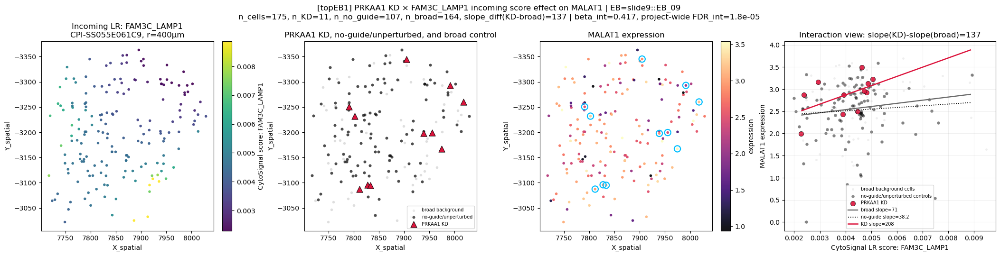

  plotting topEB2: EB=slide7::EB_51, slope_diff=8.7
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_51_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_51_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_51_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_51_cells.csv


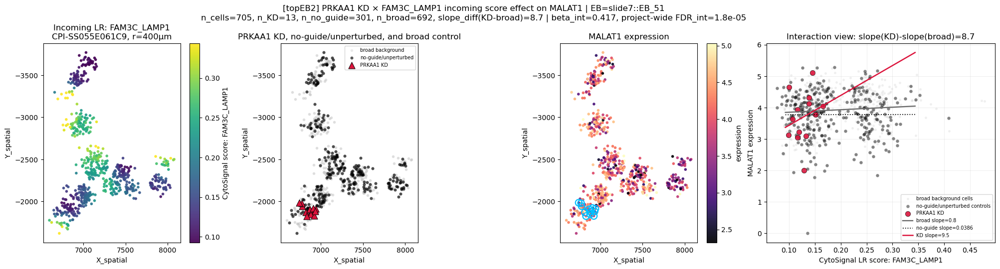

  plotting topEB3: EB=slide9::EB_40, slope_diff=-5.47
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_40_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_40_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_40_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-SS055E061C9__r400um__slide9_EB_40_cells.csv


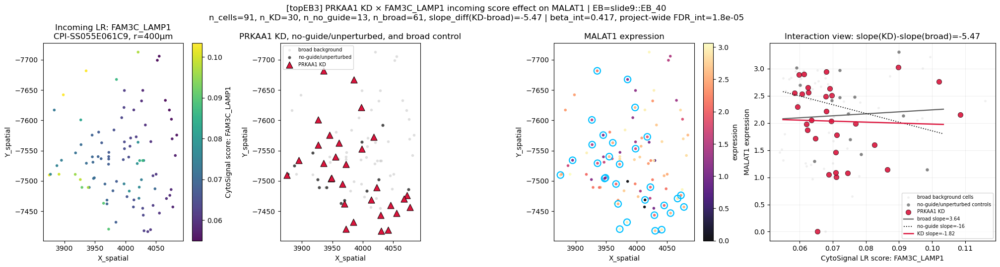


[37] interaction-aware EB selection for MAP3K15 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × RYR2, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide7::EB_34,2190,13,1012,2177,not_current_target_exclude_ambiguous,True,0.997717,2185,0.560731,1228,0.336294,0.797367,1.0,13,0.769231,10,0.997703,2172,0.559486,1218,0.845560,0.749062,1.883433,0.384230,1.499203,1.499203,0.083392,0.393878,0.47727,1.0,True,0.729135,0.162279,0.566856,1.296261,0.317427,0.978834,True,123.876329
1,slide7::EB_17,2046,10,1057,2036,not_current_target_exclude_ambiguous,True,0.991691,2029,0.513685,1051,0.286924,0.752197,1.0,10,0.700000,7,0.991650,2019,0.512770,1044,0.957521,0.669661,0.778590,0.477318,0.301272,0.301272,0.083392,0.393878,0.47727,1.0,True,0.491095,0.181486,0.309608,1.160726,0.364697,0.796029,True,56.059779
2,slide9::EB_07,248,12,67,236,not_current_target_exclude_ambiguous,True,0.995968,247,0.439516,109,0.154675,0.482125,1.0,12,0.416667,5,0.995763,235,0.440678,104,0.298033,0.308472,0.744916,0.327752,0.417164,0.417164,0.083392,0.393878,0.47727,1.0,True,0.254204,0.104822,0.149382,0.279953,0.162301,0.117651,True,49.990442
3,slide7::EB_65,353,10,146,343,not_current_target_exclude_ambiguous,True,0.997167,352,0.569405,201,0.249324,0.653858,1.0,10,0.700000,7,0.997085,342,0.565598,194,0.408051,0.657030,-0.585084,0.294413,-0.879497,-0.879497,0.083392,0.393878,0.47727,1.0,False,-0.131025,0.113607,-0.244633,-0.327771,0.147176,-0.474948,False,46.469875


  plotting topEB1: EB=slide7::EB_34, slope_diff=1.5
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_34_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_34_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_34_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_34_cells.csv


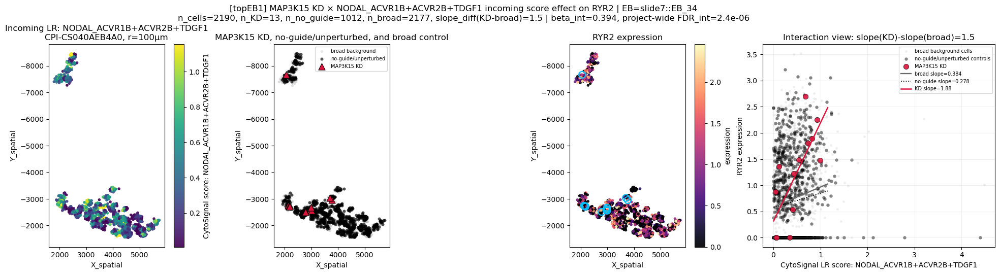

  plotting topEB2: EB=slide7::EB_17, slope_diff=0.301
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide7_EB_17_cells.csv


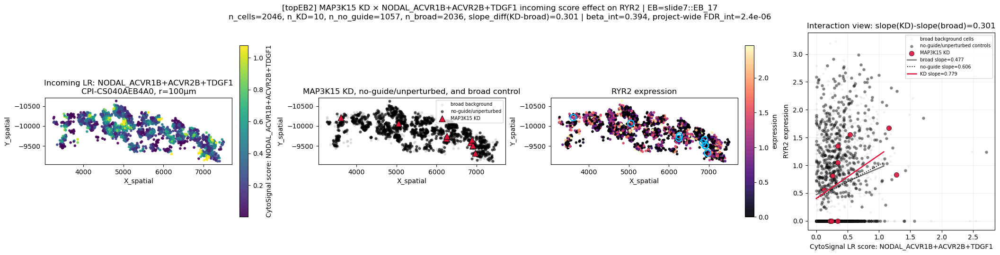

  plotting topEB3: EB=slide9::EB_07, slope_diff=0.417
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAP3K15__RYR2__CPI-CS040AEB4A0__r100um__slide9_EB_07_cells.csv


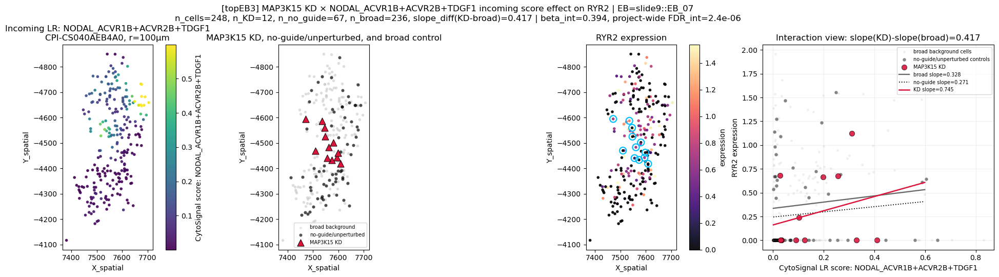


[38] interaction-aware EB selection for PTK7 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × XACT, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide8::EB_05,60,8,34,52,not_current_target_exclude_ambiguous,True,1.0,60,0.850000,51,0.021409,0.983099,1.0,8,1.000000,8,1.0,52,0.826923,43,0.037814,0.052801,20.871641,-7.671882,28.543523,28.543523,0.102881,0.600156,0.703037,1.0,True,0.643167,-0.169194,0.812361,0.504196,-0.351138,0.855334,True,1365.311702
1,slide9::EB_07,248,14,67,234,not_current_target_exclude_ambiguous,True,1.0,248,0.608871,151,0.074722,0.602125,1.0,14,0.571429,8,1.0,234,0.611111,143,0.078292,0.189617,-3.142627,1.523756,-4.666383,-4.666383,0.102881,0.600156,0.703037,1.0,False,-0.151007,0.195005,-0.346012,-0.415520,0.272656,-0.688176,False,219.604334


  plotting topEB1: EB=slide8::EB_05, slope_diff=28.5
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide8_EB_05_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide8_EB_05_cells.csv


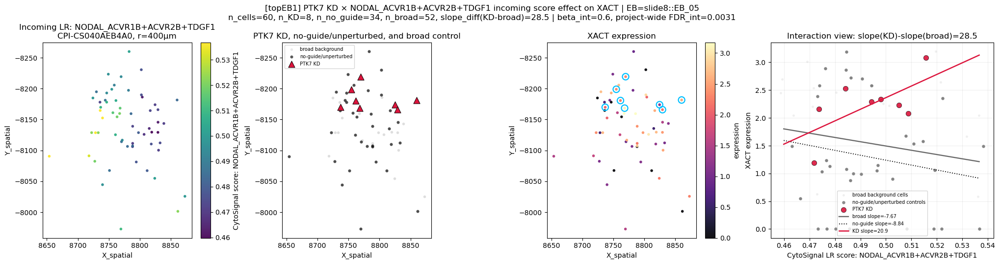

  plotting topEB2: EB=slide9::EB_07, slope_diff=-4.67
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PTK7__XACT__CPI-CS040AEB4A0__r400um__slide9_EB_07_cells.csv


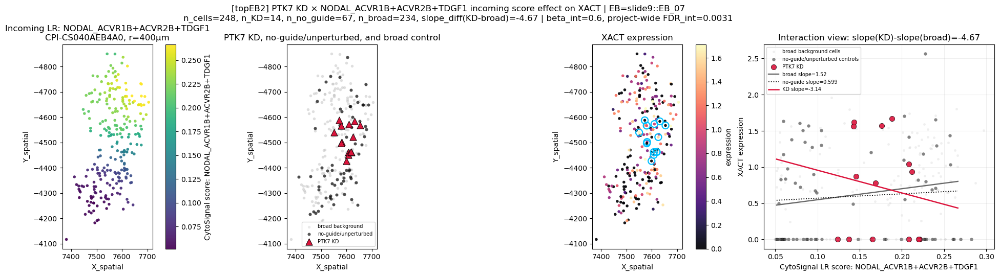


[39] interaction-aware EB selection for CDC42BPA KD × BDNF_F11R (CPI-SS03F0B666C) × GRID2, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide2::EB_75,238,8,153,230,not_current_target_exclude_ambiguous,True,1.0,238,0.995798,237,0.003856,0.727285,1.0,8,1.0,8,1.0,230,0.995652,229,0.006144,0.008721,-112.085573,-13.034874,-99.050699,-99.050699,0.238579,0.347199,0.585778,1.0,False,-0.511487,-0.069741,-0.441746,-0.721869,0.037395,-0.759264,False,5849.809699
1,slide8::EB_90,589,14,323,575,not_current_target_exclude_ambiguous,True,1.0,589,0.984720,580,0.030337,0.893038,1.0,14,1.0,14,1.0,575,0.984348,566,0.027350,0.075721,-25.040964,5.167557,-30.208521,-30.208521,0.238579,0.347199,0.585778,1.0,False,-0.640270,0.174033,-0.814303,-0.594592,0.356991,-0.951583,False,1522.756583
2,slide5::EB_07,389,10,230,379,not_current_target_exclude_ambiguous,True,1.0,389,0.845758,329,0.034577,1.066849,1.0,10,0.8,8,1.0,379,0.846966,321,0.001624,0.094540,-19.774620,-0.553304,-19.221316,-19.221316,0.238579,0.347199,0.585778,1.0,False,-0.021506,-0.017815,-0.003691,-0.180687,-0.167387,-0.013300,False,1074.615947
3,slide8::EB_34,409,13,184,396,not_current_target_exclude_ambiguous,True,1.0,409,0.973105,398,0.034173,0.962278,1.0,13,1.0,13,1.0,396,0.972222,385,0.010084,0.090452,-13.908498,5.157946,-19.066445,-19.066445,0.238579,0.347199,0.585778,1.0,False,-0.106047,0.179290,-0.285337,-0.127768,0.357891,-0.485659,False,900.293094


  plotting topEB1: EB=slide2::EB_75, slope_diff=-99.1
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide2_EB_75_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide2_EB_75_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide2_EB_75_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide2_EB_75_cells.csv


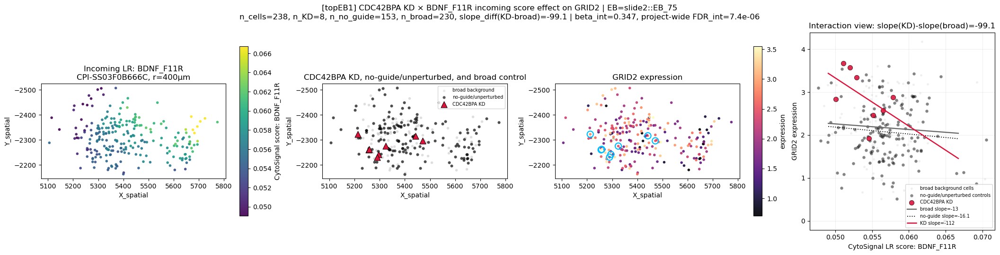

  plotting topEB2: EB=slide8::EB_90, slope_diff=-30.2
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide8_EB_90_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide8_EB_90_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide8_EB_90_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide8_EB_90_cells.csv


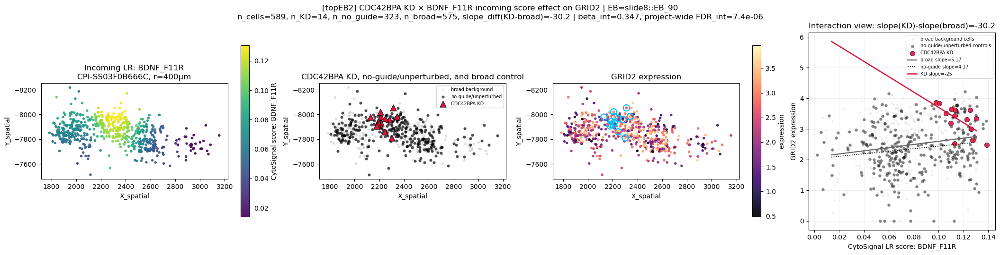

  plotting topEB3: EB=slide5::EB_07, slope_diff=-19.2
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide5_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide5_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide5_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__CDC42BPA__GRID2__CPI-SS03F0B666C__r400um__slide5_EB_07_cells.csv


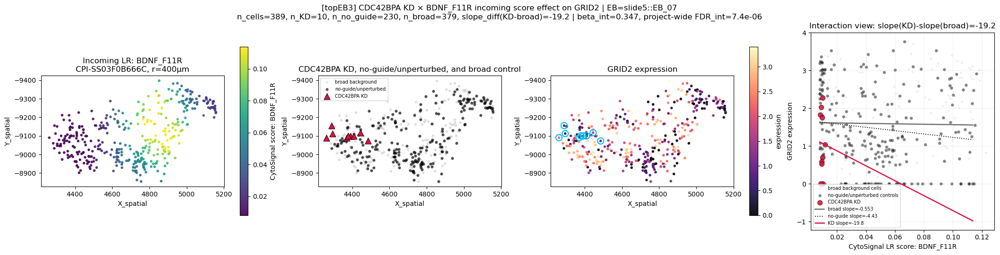


[40] interaction-aware EB selection for MAP4K2 KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=200µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide6::EB_12,2112,10,1405,2102,not_current_target_exclude_ambiguous,True,1.0,2112,1.0,2112,0.142493,0.565691,1.0,10,1.0,10,1.0,2102,1.0,2102,0.273829,0.370195,-0.828397,-0.098419,-0.729978,-0.729978,0.09613,0.530992,0.627122,1.0,False,-0.152169,-0.02486,-0.127308,0.023248,-0.017886,0.041134,True,49.527354


  plotting topEB1: EB=slide6::EB_12, slope_diff=-0.73
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP4K2__MALAT1__CPI-SS006C6537E__r200um__slide6_EB_12_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP4K2__MALAT1__CPI-SS006C6537E__r200um__slide6_EB_12_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP4K2__MALAT1__CPI-SS006C6537E__r200um__slide6_EB_12_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAP4K2__MALAT1__CPI-SS006C6537E__r200um__slide6_EB_12_cells.csv


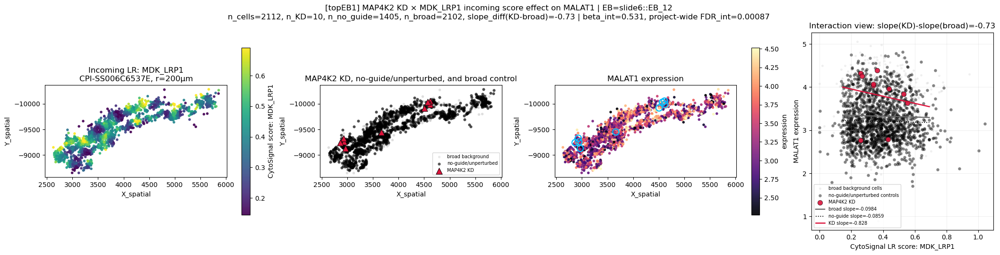


[41] interaction-aware EB selection for EPHA6 KD × SEMA3A_NRP1+PLXNA2 (CPI-CS0D238C22B) × DSCAM, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_14,72,8,18,64,not_current_target_exclude_ambiguous,True,1.0,72,0.430556,31,0.016648,0.459739,1.0,8,0.625000,5,1.0,64,0.406250,26,0.019883,0.040869,22.922262,-1.623282,24.545544,24.545544,0.084398,0.187025,0.271424,1.0,True,0.461649,-0.062194,0.523843,0.352292,-0.047511,0.399803,True,1321.328096
1,slide5::EB_15,217,18,104,199,not_current_target_exclude_ambiguous,True,1.0,217,0.207373,45,0.054417,0.699910,1.0,18,0.166667,3,1.0,199,0.211055,42,0.124110,0.137604,8.033258,2.695597,5.337661,5.337661,0.084398,0.187025,0.271424,1.0,True,0.528815,0.209847,0.318968,0.944479,0.440070,0.504410,True,397.742512
2,slide8::EB_115,637,19,412,618,not_current_target_exclude_ambiguous,True,1.0,637,0.166405,106,0.026364,0.425865,1.0,19,0.263158,5,1.0,618,0.163430,101,0.062989,0.057473,-3.935690,1.511052,-5.446741,-5.446741,0.084398,0.187025,0.271424,1.0,False,-0.416020,0.092135,-0.508155,-0.303984,0.064199,-0.368183,False,264.786345
3,slide8::EB_98,169,14,92,155,not_current_target_exclude_ambiguous,True,1.0,169,0.218935,37,0.061248,0.406069,1.0,14,0.285714,4,1.0,155,0.212903,33,0.073391,0.146662,5.108679,1.441452,3.667227,3.667227,0.084398,0.187025,0.271424,1.0,True,0.445275,0.215093,0.230181,0.310647,0.239908,0.070739,True,263.635361
4,slide7::EB_17,2046,22,1057,2024,not_current_target_exclude_ambiguous,True,1.0,2046,0.200391,410,0.164454,0.604798,1.0,22,0.500000,11,1.0,2024,0.197134,399,0.395622,0.360403,1.544571,0.871625,0.672946,0.672946,0.084398,0.187025,0.271424,1.0,True,0.564083,0.234660,0.329423,0.963371,0.327822,0.635549,True,89.095392
5,slide7::EB_34,2190,29,1012,2161,not_current_target_exclude_ambiguous,True,1.0,2190,0.205479,450,0.175920,0.563373,1.0,29,0.206897,6,1.0,2161,0.205460,444,0.269756,0.457007,1.557097,1.059943,0.497153,0.497153,0.084398,0.187025,0.271424,1.0,True,0.307269,0.332602,-0.025334,0.144992,0.358883,-0.213891,False,77.192177
6,slide8::EB_01,309,11,139,298,not_current_target_exclude_ambiguous,True,1.0,309,0.226537,70,0.166589,0.728116,1.0,11,1.000000,11,1.0,298,0.197987,59,0.154532,0.390676,1.636009,1.604227,0.031782,0.031782,0.084398,0.187025,0.271424,1.0,True,0.275997,0.379116,-0.103119,0.295315,0.551018,-0.255704,False,64.434684
7,slide8::EB_37,169,17,83,152,not_current_target_exclude_ambiguous,True,1.0,169,0.153846,26,0.114565,0.420113,1.0,17,0.176471,3,1.0,152,0.151316,23,0.051985,0.297846,0.340505,-0.133088,0.473594,0.473594,0.084398,0.187025,0.271424,1.0,True,0.028215,-0.035800,0.064015,0.136413,-0.021686,0.158099,True,37.776749


  plotting topEB1: EB=slide9::EB_14, slope_diff=24.5
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide9_EB_14_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide9_EB_14_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide9_EB_14_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide9_EB_14_cells.csv


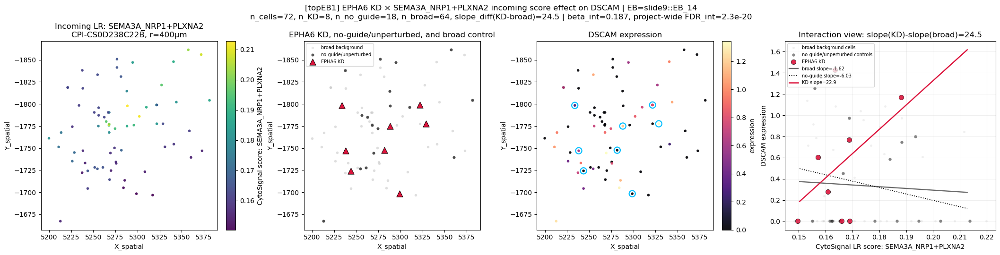

  plotting topEB2: EB=slide5::EB_15, slope_diff=5.34
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide5_EB_15_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide5_EB_15_cells.csv


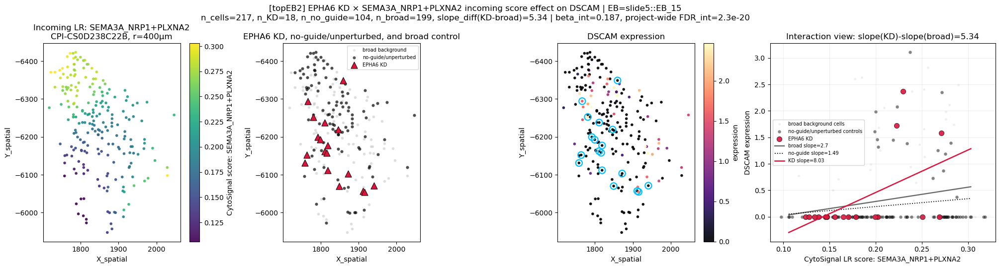

  plotting topEB3: EB=slide8::EB_115, slope_diff=-5.45
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide8_EB_115_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide8_EB_115_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide8_EB_115_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__EPHA6__DSCAM__CPI-CS0D238C22B__r400um__slide8_EB_115_cells.csv


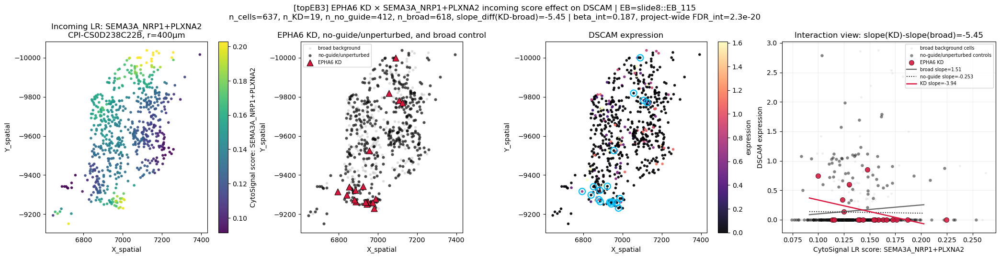


[42] interaction-aware EB selection for BMP2K KD × MDK_LRP1 (CPI-SS006C6537E) × SOX5, radius=200µm
  skipped: no EB passed interaction-aware filters

[43] interaction-aware EB selection for JAK1 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide7::EB_17,2046,8,1057,2038,not_current_target_exclude_ambiguous,True,1.0,2046,0.999022,2044,0.041850,0.669474,1.0,8,1.0,8,1.0,2038,0.999019,2036,0.089715,0.095306,4.870807,-0.811268,5.682075,5.682075,0.117648,0.38522,0.502868,1.0,True,0.412195,-0.050690,0.462884,0.712205,-0.092116,0.804322,True,310.964897
1,slide6::EB_14,683,13,466,670,not_current_target_exclude_ambiguous,True,1.0,683,1.000000,683,0.033984,0.581055,1.0,13,1.0,13,1.0,670,1.000000,670,0.085980,0.074791,-4.427333,-0.512640,-3.914693,-3.914693,0.117648,0.38522,0.502868,1.0,False,-0.371006,-0.029478,-0.341528,-0.350737,0.004238,-0.354975,False,238.820891
2,slide7::EB_34,2190,12,1012,2178,not_current_target_exclude_ambiguous,True,1.0,2190,1.000000,2190,0.047266,0.652838,1.0,12,1.0,12,1.0,2178,1.000000,2178,0.106154,0.125864,-2.832150,1.837063,-4.669213,-4.669213,0.117648,0.38522,0.502868,1.0,False,-0.378681,0.132634,-0.511315,-0.710445,0.177604,-0.888049,False,213.815849


  plotting topEB1: EB=slide7::EB_17, slope_diff=5.68
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_17_cells.csv


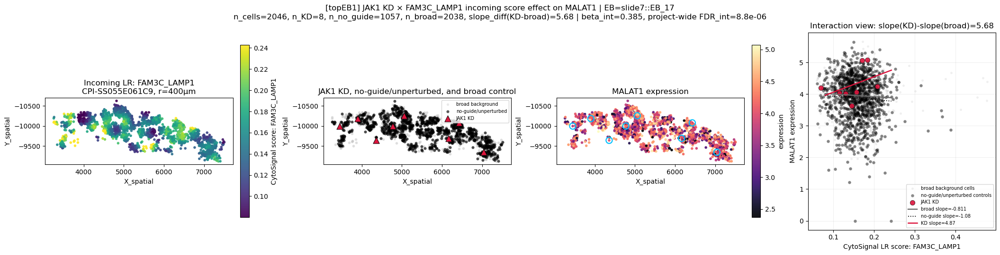

  plotting topEB2: EB=slide6::EB_14, slope_diff=-3.91
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide6_EB_14_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide6_EB_14_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide6_EB_14_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide6_EB_14_cells.csv


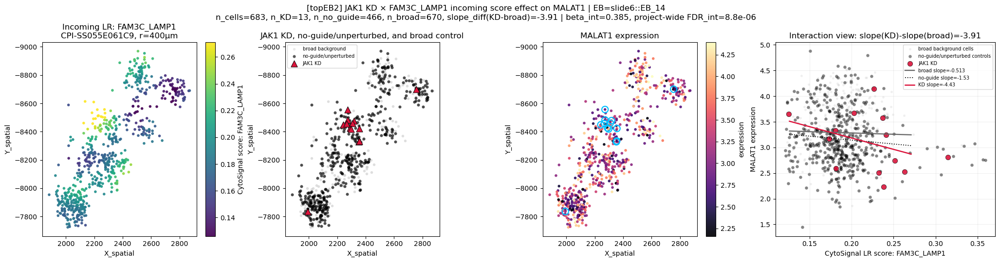

  plotting topEB3: EB=slide7::EB_34, slope_diff=-4.67
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_34_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_34_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_34_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__JAK1__MALAT1__CPI-SS055E061C9__r400um__slide7_EB_34_cells.csv


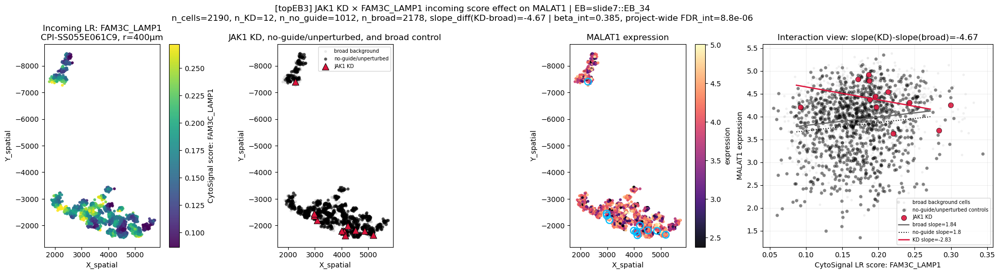


[44] interaction-aware EB selection for MAPK6 KD × MDK_LRP1 (CPI-SS006C6537E) × MALAT1, radius=400µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_39,57,9,17,48,not_current_target_exclude_ambiguous,True,1.0,57,0.982456,56,0.011548,0.600763,1.0,9,1.0,9,1.0,48,0.979167,47,0.020492,0.030560,-8.744664,-0.862740,-7.881924,-7.881924,0.118531,0.369905,0.488436,1.0,False,-0.288720,-0.015600,-0.273119,-0.551223,0.114898,-0.666120,False,466.403984
1,slide9::EB_50,87,16,31,71,not_current_target_exclude_ambiguous,True,1.0,87,0.965517,84,0.009941,0.713968,1.0,16,1.0,16,1.0,71,0.957746,68,0.021301,0.027740,6.051577,1.657767,4.393811,4.393811,0.118531,0.369905,0.488436,1.0,True,0.100367,0.022563,0.077804,0.124784,0.056935,0.067848,True,305.965052
2,slide6::EB_12,2112,11,1405,2101,not_current_target_exclude_ambiguous,True,1.0,2112,1.000000,2112,0.076939,0.565691,1.0,11,1.0,11,1.0,2101,1.000000,2101,0.101376,0.211320,4.777402,-0.199196,4.976598,4.976598,0.118531,0.369905,0.488436,1.0,True,0.329508,-0.027223,0.356731,0.089602,-0.027966,0.117567,True,285.923387
3,slide8::EB_61,118,8,53,110,not_current_target_exclude_ambiguous,True,1.0,118,1.000000,118,0.026097,0.581302,1.0,8,1.0,8,1.0,110,1.000000,110,0.062949,0.061379,-1.056823,2.160218,-3.217041,-3.217041,0.118531,0.369905,0.488436,1.0,False,-0.148479,0.093064,-0.241543,-0.069204,0.080993,-0.150198,False,115.299359


  plotting topEB1: EB=slide9::EB_39, slope_diff=-7.88
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_39_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_39_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_39_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_39_cells.csv


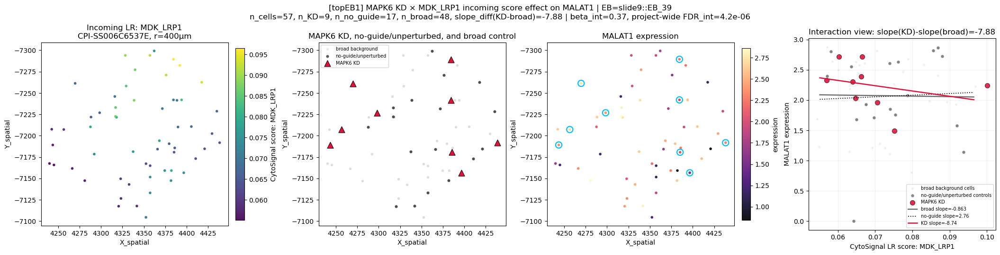

  plotting topEB2: EB=slide9::EB_50, slope_diff=4.39
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_50_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_50_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_50_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide9_EB_50_cells.csv


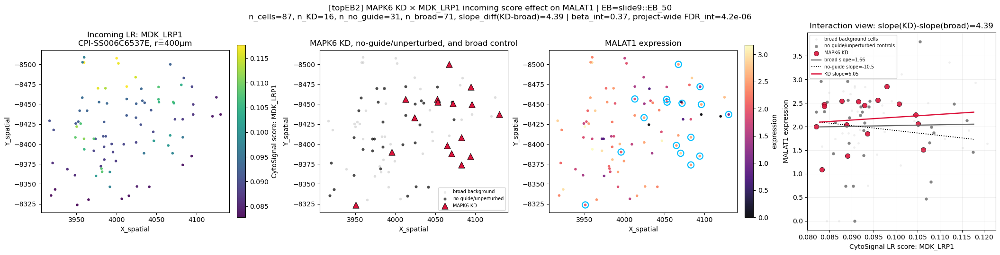

  plotting topEB3: EB=slide6::EB_12, slope_diff=4.98
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide6_EB_12_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide6_EB_12_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide6_EB_12_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__MAPK6__MALAT1__CPI-SS006C6537E__r400um__slide6_EB_12_cells.csv


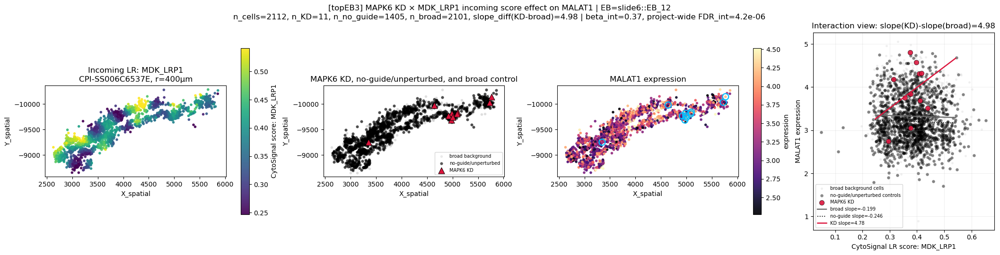


[45] interaction-aware EB selection for ROR1 KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide5::EB_02,692,15,326,677,not_current_target_exclude_ambiguous,True,1.000000,692,0.99711,690,0.098233,0.663646,1.0,15,1.0,15,1.000000,677,0.997046,675,0.147306,0.245256,1.213978,-0.728529,1.942507,1.942507,0.068287,0.634956,0.703242,1.0,True,0.146612,-0.108125,0.254737,0.235689,-0.162298,0.397987,True,103.795071
1,slide6::EB_06,107,11,61,96,not_current_target_exclude_ambiguous,True,0.990654,106,1.00000,107,0.070235,0.570522,1.0,11,1.0,11,0.989583,95,1.000000,96,0.187185,0.161803,-0.121144,0.586730,-0.707874,-0.707874,0.068287,0.634956,0.703242,1.0,False,-0.027625,0.070368,-0.097993,0.258795,0.067196,0.191599,True,26.847452


  plotting topEB1: EB=slide5::EB_02, slope_diff=1.94
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide5_EB_02_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide5_EB_02_cells.csv


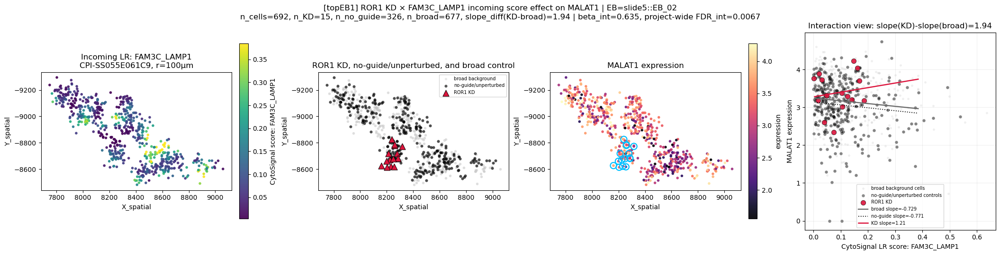

  plotting topEB2: EB=slide6::EB_06, slope_diff=-0.708
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide6_EB_06_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__ROR1__MALAT1__CPI-SS055E061C9__r100um__slide6_EB_06_cells.csv


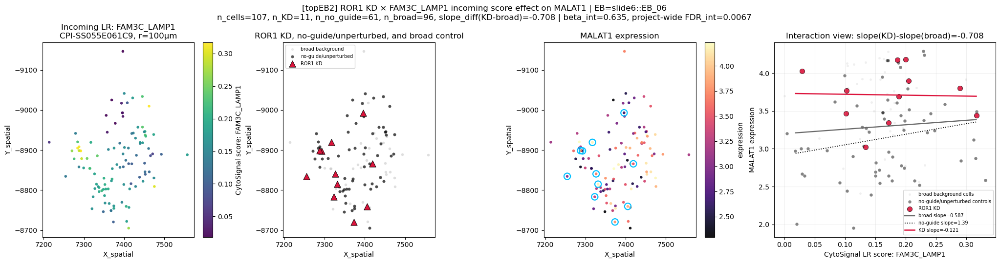


[46] interaction-aware EB selection for PRKAA1 KD × NODAL_ACVR1B+ACVR2B+TDGF1 (CPI-CS040AEB4A0) × MALAT1, radius=200µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_40,91,30,13,61,not_current_target_exclude_ambiguous,True,1.0,91,0.967033,88,0.027727,0.754628,1.0,30,0.966667,29,1.0,61,0.967213,59,0.067324,0.066885,8.646045,-3.527166,12.173211,12.173211,0.067757,0.413076,0.480833,1.0,True,0.347568,-0.120939,0.468506,0.502675,-0.128830,0.631505,True,588.418551
1,slide9::EB_09,175,11,107,164,not_current_target_exclude_ambiguous,True,1.0,175,0.988571,173,0.041602,0.645406,1.0,11,1.000000,11,1.0,164,0.987805,162,0.104687,0.109479,3.484917,2.119546,1.365371,1.365371,0.067757,0.413076,0.480833,1.0,True,0.370342,0.134515,0.235827,0.291916,0.170487,0.121430,True,156.543712
2,slide7::EB_51,705,13,301,692,not_current_target_exclude_ambiguous,True,1.0,705,0.998582,704,0.211129,0.667674,1.0,13,1.000000,13,1.0,692,0.998555,691,0.260366,0.496308,-0.932729,-0.358507,-0.574223,-0.574223,0.067757,0.413076,0.480833,1.0,False,-0.119463,-0.114585,-0.004879,-0.132507,-0.128548,-0.003959,False,45.334254


  plotting topEB1: EB=slide9::EB_40, slope_diff=12.2
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_40_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_40_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_40_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_40_cells.csv


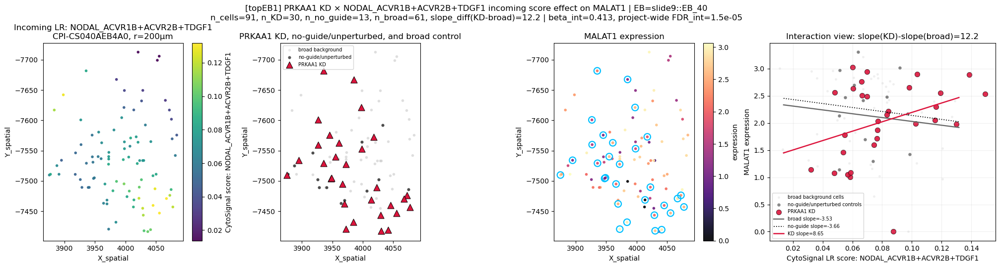

  plotting topEB2: EB=slide9::EB_09, slope_diff=1.37
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_09_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_09_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_09_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide9_EB_09_cells.csv


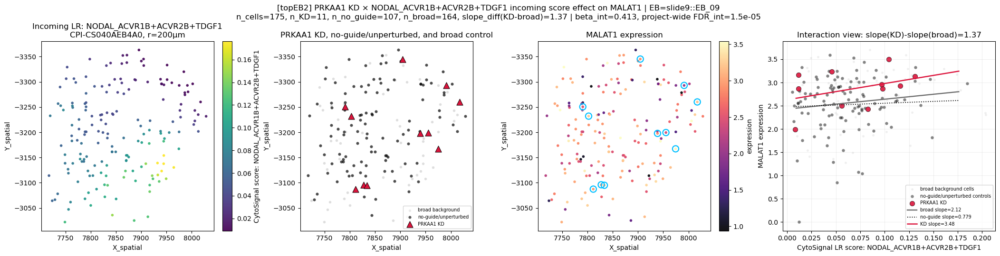

  plotting topEB3: EB=slide7::EB_51, slope_diff=-0.574
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide7_EB_51_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide7_EB_51_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide7_EB_51_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__PRKAA1__MALAT1__CPI-CS040AEB4A0__r200um__slide7_EB_51_cells.csv


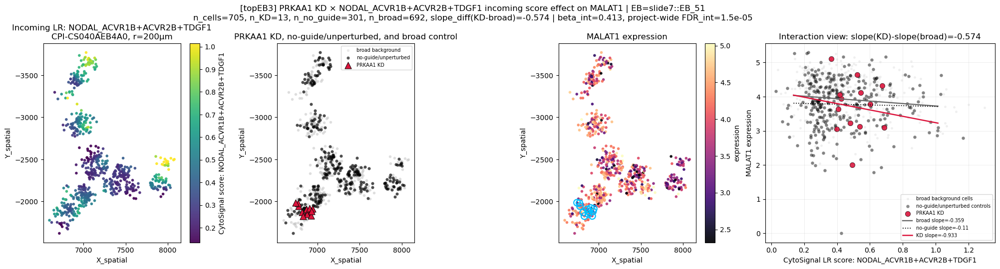


[47] interaction-aware EB selection for BMP2K KD × MDK_LRP1 (CPI-SS006C6537E) × NAV3, radius=200µm
  skipped: no EB passed interaction-aware filters

[48] interaction-aware EB selection for BCKDK KD × FAM3C_LAMP1 (CPI-SS055E061C9) × MALAT1, radius=100µm


,eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,qc_passed,all_lr_nonzero_fraction,all_n_lr_nonzero,all_gene_expressed_fraction,all_n_gene_expressed,all_lr_score_sd,all_gene_expression_sd,kd_lr_nonzero_fraction,kd_n_lr_nonzero,kd_gene_expressed_fraction,kd_n_gene_expressed,broad_lr_nonzero_fraction,broad_n_lr_nonzero,broad_gene_expressed_fraction,broad_n_gene_expressed,kd_score_range,control_score_range,slope_kd,slope_control,slope_diff_kd_minus_broad_control,slope_diff_kd_minus_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,expected_sign_from_beta_interaction,slope_diff_direction_agrees,kd_score_gene_corr,control_score_gene_corr,corr_diff_kd_minus_control,kd_high_minus_low_expr,control_high_minus_low_expr,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score
0,slide9::EB_07,248,13,67,235,not_current_target_exclude_ambiguous,True,0.975806,242,0.959677,238,0.075304,0.760178,0.923077,12,0.846154,11,0.978723,230,0.965957,227,0.009903,0.145513,89.326730,2.170765,87.155966,87.155966,0.068327,0.458109,0.526436,1.0,True,0.472408,0.224379,0.248029,0.811178,0.169385,0.641793,True,4880.800177
1,slide9::EB_17,77,12,31,65,not_current_target_exclude_ambiguous,True,0.987013,76,0.948052,73,0.089622,0.794479,1.000000,12,1.000000,12,0.984615,64,0.938462,61,0.051171,0.167297,2.321104,-0.339979,2.661082,2.661082,0.068327,0.458109,0.526436,1.0,True,0.295769,-0.037777,0.333546,0.268631,-0.013707,0.282338,True,154.165896
2,slide2::EB_36,156,8,97,148,not_current_target_exclude_ambiguous,True,0.993590,155,1.000000,156,0.128063,0.697174,1.000000,8,1.000000,8,0.993243,147,1.000000,148,0.264110,0.306041,0.033626,1.112446,-1.078820,-1.078820,0.068327,0.458109,0.526436,1.0,False,0.009694,0.197128,-0.187433,-0.295420,0.364021,-0.659441,False,33.788393


  plotting topEB1: EB=slide9::EB_07, slope_diff=87.2
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_07_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_07_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_07_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB1__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_07_cells.csv


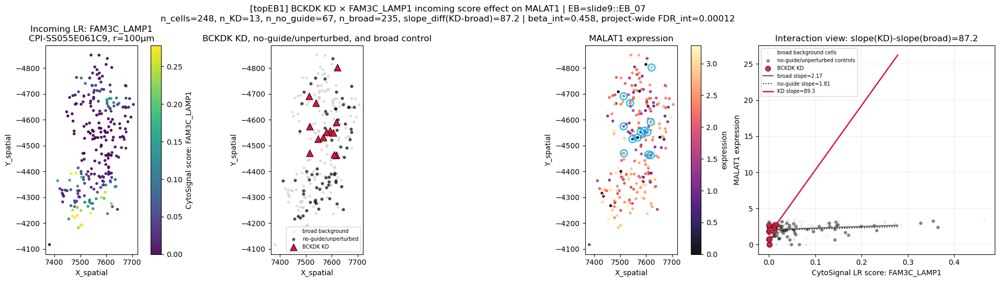

  plotting topEB2: EB=slide9::EB_17, slope_diff=2.66
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_17_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_17_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_17_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB2__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide9_EB_17_cells.csv


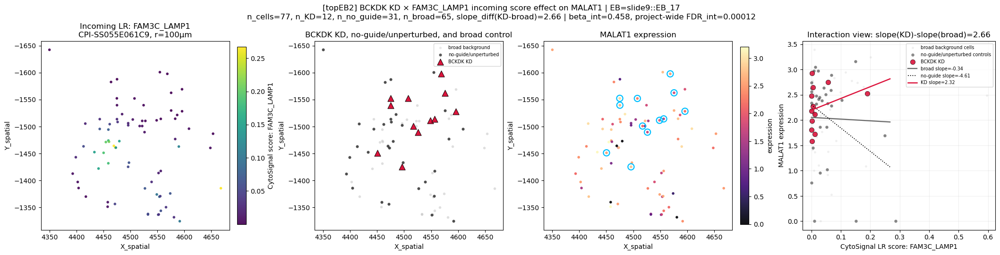

  plotting topEB3: EB=slide2::EB_36, slope_diff=-1.08
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide2_EB_36_kinase_lr_interaction_map.png
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide2_EB_36_kinase_lr_interaction_map.pdf
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide2_EB_36_kinase_lr_interaction_map.svg
Saved: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/topEB3__BCKDK__MALAT1__CPI-SS055E061C9__r100um__slide2_EB_36_cells.csv


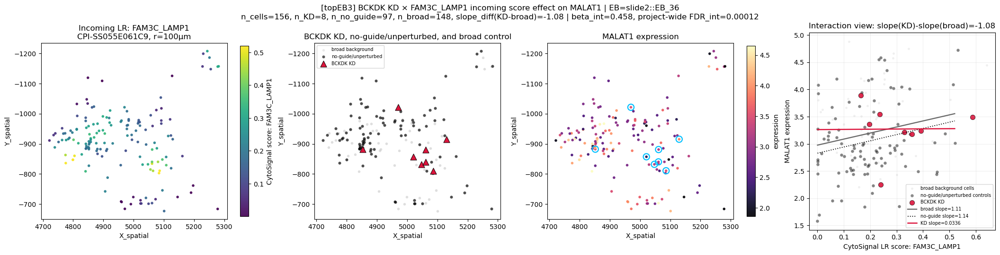


[49] interaction-aware EB selection for MAP3K2 KD × FGF2_FGFR1 (CPI-SS01F67987A) × AHRR, radius=400µm
  skipped: no EB passed interaction-aware filters

Saved batch summary: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/interaction_aware_top_candidate_story_maps/kinase_lr_interaction_aware_top_candidate_story_map_summary.csv


,candidate_rank,candidate_eb_rank,target,radius_um,lr_var_name,gene,status,lr_display_name,lr_name,ligand_name,receptor_name,selected_eb,n_cells,n_kd,n_control,n_broad_control,broad_control_mode,slope_kd,slope_control,slope_diff_kd_minus_broad_control,beta_lr,beta_interaction,model_kd_conditional_lr_slope,slope_diff_direction_agrees,delta_diff_kd_minus_control,delta_diff_direction_agrees,interaction_aware_rank_score,fdr_interaction,fdr_interaction_projectwide,target_role,candidate_type
0,0,NaN,MAST3,400,CPI-SS0472C478C,MALAT1,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,MAST3,400,CPI-CS040AEB4A0,MALAT1,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,MAST3,200,CPI-CS040AEB4A0,MALAT1,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,PDK3,100,CPI-CS040AEB4A0,GRID2,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,MAST3,400,CPI-SS01F67987A,MALAT1,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,47,NaN,BMP2K,200,CPI-SS006C6537E,NAV3,skipped_no_interaction_aware_eb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,48,1.0,BCKDK,100,CPI-SS055E061C9,MALAT1,plotted,FAM3C_LAMP1,FAM3C_LAMP1,NaN,NaN,slide9::EB_07,248.0,13.0,67.0,235.0,not_current_target_exclude_ambiguous,89.326730,2.170765,87.155966,0.068327,0.458109,0.526436,True,0.641793,True,4880.800177,0.00003,0.000116,,
89,48,2.0,BCKDK,100,CPI-SS055E061C9,MALAT1,plotted,FAM3C_LAMP1,FAM3C_LAMP1,NaN,NaN,slide9::EB_17,77.0,12.0,31.0,65.0,not_current_target_exclude_ambiguous,2.321104,-0.339979,2.661082,0.068327,0.458109,0.526436,True,0.282338,True,154.165896,0.00003,0.000116,,
90,48,3.0,BCKDK,100,CPI-SS055E061C9,MALAT1,plotted,FAM3C_LAMP1,FAM3C_LAMP1,NaN,NaN,slide2::EB_36,156.0,8.0,97.0,148.0,not_current_target_exclude_ambiguous,0.033626,1.112446,-1.078820,0.068327,0.458109,0.526436,False,-0.659441,False,33.788393,0.00003,0.000116,,


In [9]:
BATCH_OUTPUT_DIR = OUTPUT_DIR / 'interaction_aware_top_candidate_story_maps'
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

batch_rows = []
for candidate_rank, row in best_candidates.head(N_INTERACTION_AWARE_CANDIDATES).iterrows():
    target = str(row['target'])
    radius_um = int(row['radius_um'])
    lr_var_name = str(row['lr_var_name'])
    lr_display_name = str(row.get('lr_display_name', lr_var_name))
    gene = str(row['gene'])
    print(f"\n[{candidate_rank}] interaction-aware EB selection for {target} KD × {lr_display_name} ({lr_var_name}) × {gene}, radius={radius_um}µm")
    try:
        frame, resolved_gene = make_candidate_plot_metadata(target, radius_um, lr_var_name, gene)
        eb_rank = summarize_interaction_aware_ebs(frame, gene, row)
        if eb_rank.empty:
            print('  skipped: no EB passed interaction-aware filters')
            batch_rows.append({
                'candidate_rank': candidate_rank,
                'candidate_eb_rank': np.nan,
                'target': target,
                'radius_um': radius_um,
                'lr_var_name': lr_var_name,
                'gene': gene,
                'status': 'skipped_no_interaction_aware_eb',
            })
            continue
        display(eb_rank.head(max(10, TOP_EBS_PER_CANDIDATE)))
        for eb_i, (_, selected) in enumerate(eb_rank.head(TOP_EBS_PER_CANDIDATE).iterrows(), start=1):
            label = f'topEB{eb_i}'
            print(f'  plotting {label}: EB={selected["eb"]}, slope_diff={selected["slope_diff_kd_minus_control"]:.3g}')
            fig, cells = plot_kinase_lr_eb_map(
                frame,
                target,
                radius_um,
                lr_var_name,
                gene,
                selected['eb'],
                model_row=row,
                output_dir=BATCH_OUTPUT_DIR,
                figure_label=label,
            )
            plt.show()
            batch_rows.append({
                'candidate_rank': candidate_rank,
                'candidate_eb_rank': eb_i,
                'target': target,
                'radius_um': radius_um,
                'lr_var_name': lr_var_name,
                'lr_display_name': row.get('lr_display_name', lr_var_name),
                'lr_name': row.get('lr_name', ''),
                'ligand_name': row.get('ligand_name', ''),
                'receptor_name': row.get('receptor_name', ''),
                'gene': gene,
                'selected_eb': selected['eb'],
                'n_cells': int(selected['n_cells']),
                'n_kd': int(selected['n_kd']),
                'n_control': int(selected['n_control']),
                'n_broad_control': int(selected.get('n_broad_control', np.nan)),
                'broad_control_mode': selected.get('broad_control_mode', BROAD_CONTROL_MODE),
                'slope_kd': selected['slope_kd'],
                'slope_control': selected['slope_control'],
                'slope_diff_kd_minus_broad_control': selected['slope_diff_kd_minus_control'],
                'beta_lr': selected.get('beta_lr', row.get('beta_lr', np.nan)),
                'beta_interaction': selected['beta_interaction'],
                'model_kd_conditional_lr_slope': selected.get('model_kd_conditional_lr_slope', row.get('kd_conditional_lr_slope', np.nan)),
                'slope_diff_direction_agrees': selected['slope_diff_direction_agrees'],
                'delta_diff_kd_minus_control': selected['delta_diff_kd_minus_control'],
                'delta_diff_direction_agrees': selected['delta_diff_direction_agrees'],
                'interaction_aware_rank_score': selected['interaction_aware_rank_score'],
                'fdr_interaction': row.get('fdr_interaction', np.nan),
                'fdr_interaction_projectwide': row.get('fdr_interaction_projectwide', np.nan),
                'target_role': row.get('target_role', ''),
                'candidate_type': row.get('candidate_type', ''),
                'status': 'plotted',
            })
    except Exception as exc:
        print('  failed:', repr(exc))
        batch_rows.append({
            'candidate_rank': candidate_rank,
            'candidate_eb_rank': np.nan,
            'target': target,
            'radius_um': radius_um,
            'lr_var_name': lr_var_name,
            'gene': gene,
            'status': 'failed',
            'error': repr(exc),
        })

batch_summary = pd.DataFrame(batch_rows)
summary_path = BATCH_OUTPUT_DIR / 'kinase_lr_interaction_aware_top_candidate_story_map_summary.csv'
batch_summary.to_csv(summary_path, index=False)
print('\nSaved batch summary:', summary_path)
display(batch_summary)

## 6. Kinase x LR-score directional GO analysis across radii

This section defines one gene set for each `kinase x LR score x direction`. Genes enter the set when their `KD x LR score` interaction passes project-wide FDR in any radius. Radius is treated as a scale/sensitivity parameter and is merged away.

Direction is defined by the sign of `beta_interaction` among significant supporting radii:

- positive: all significant supporting radii have `beta_interaction > 0`
- negative: all significant supporting radii have `beta_interaction < 0`
- conflict: both signs are present across radii; these genes are audited and excluded from GO

GO is run for `GO_Biological_Process_2023` and `GO_Molecular_Function_2023`. Project-wide GO FDR is computed separately within each ontology and direction family.


Directional support rows: 15955
Directional conflicts excluded: 0
Directional gene sets: 1972
Eligible GO gene sets: 384


,target,lr_var_name,direction,n_genes,genes,ligand_name,receptor_name,lr_name,n_gene_radius_support_rows,min_fdr_interaction_projectwide,median_abs_beta_interaction,eligible_for_go
0,PTK2,CPI-CS040AEB4A0,positive,330,A2ML1-AS1;AC003975.1;AC007405.1;AC009315.1;AC0...,,,NODAL_ACVR1B+ACVR2B+TDGF1,330,9.086807e-18,0.064447,True
1,TTBK2,CPI-CS040AEB4A0,positive,268,ABCC1;AC005062.1;AC005520.5;AC007001.1;AC00873...,,,NODAL_ACVR1B+ACVR2B+TDGF1,268,2.394339e-07,0.069082,True
2,TTBK2,CPI-SS055E061C9,positive,243,ABR;ABTB2;AC006001.2;AC008591.1;AC015522.1;AC0...,,,FAM3C_LAMP1,243,4.045526e-09,0.062024,True
3,EPHA6,CPI-SS055E061C9,positive,229,ABCC1;ABR;AC005062.1;AC007326.5;AC008014.1;AC0...,,,FAM3C_LAMP1,229,2.067705e-11,0.126299,True
4,PTK2,CPI-SS055E061C9,positive,172,AC004830.2;AC005062.1;AC021504.1;AC073050.1;AC...,,,FAM3C_LAMP1,172,3.982136e-07,0.095705,True
5,ROCK2,CPI-CS040AEB4A0,positive,168,A2ML1-AS1;ABHD18;AC003044.1;AC005062.1;AC00766...,,,NODAL_ACVR1B+ACVR2B+TDGF1,168,8.012206e-10,0.069411,True
6,PRKD3,CPI-CS040AEB4A0,positive,130,AC004830.2;AC010168.1;AC011447.3;AC022140.1;AC...,,,NODAL_ACVR1B+ACVR2B+TDGF1,130,3.164275e-07,0.173371,True
7,MERTK,CPI-SS055E061C9,negative,123,ACTB;ACTG1;CD24;EEF1A1;EEF1G;EEF2;EIF4A1;EIF4B...,,,FAM3C_LAMP1,123,1.304777e-11,0.208819,True
8,PTK2,CPI-CS040AEB4A0,negative,119,ACTB;ACTG1;APOE;CD24;COX7C;EEF1A1;EEF1G;EEF2;E...,,,NODAL_ACVR1B+ACVR2B+TDGF1,119,8.015617e-10,0.119525,True
9,TTBK2,CPI-SS03F0B666C,positive,115,A2ML1-AS1;AASS;ABCC1;AC007666.2;AC019155.2;AC0...,,,BDNF_F11R,115,3.750833e-16,0.058524,True


GO BP: PTK2 x CPI-CS040AEB4A0 x positive (330 genes)
GO MF: PTK2 x CPI-CS040AEB4A0 x positive (330 genes)
GO BP: TTBK2 x CPI-CS040AEB4A0 x positive (268 genes)
GO MF: TTBK2 x CPI-CS040AEB4A0 x positive (268 genes)
GO BP: TTBK2 x CPI-SS055E061C9 x positive (243 genes)
GO MF: TTBK2 x CPI-SS055E061C9 x positive (243 genes)
GO BP: EPHA6 x CPI-SS055E061C9 x positive (229 genes)
GO MF: EPHA6 x CPI-SS055E061C9 x positive (229 genes)
GO BP: PTK2 x CPI-SS055E061C9 x positive (172 genes)
GO MF: PTK2 x CPI-SS055E061C9 x positive (172 genes)
GO BP: ROCK2 x CPI-CS040AEB4A0 x positive (168 genes)
GO MF: ROCK2 x CPI-CS040AEB4A0 x positive (168 genes)
GO BP: PRKD3 x CPI-CS040AEB4A0 x positive (130 genes)
GO MF: PRKD3 x CPI-CS040AEB4A0 x positive (130 genes)
GO BP: MERTK x CPI-SS055E061C9 x negative (123 genes)
GO MF: MERTK x CPI-SS055E061C9 x negative (123 genes)
GO BP: PTK2 x CPI-CS040AEB4A0 x negative (119 genes)
GO MF: PTK2 x CPI-CS040AEB4A0 x negative (119 genes)
GO BP: TTBK2 x CPI-SS03F0B666C x p

,status,n_rows
0,completed,89282
1,failed,1


,ontology,direction,n_terms,n_significant,min_projectwide_go_fdr,n_gene_sets
0,BP,negative,9620,948,4.022669e-158,39
1,BP,positive,63340,174,1.000728e-02,344
2,MF,negative,2209,423,1.317756e-70,39
3,MF,positive,14113,34,9.154186e-06,345


Saved BP positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_positive.png
Saved BP positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_positive.pdf
Saved BP positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_positive.svg


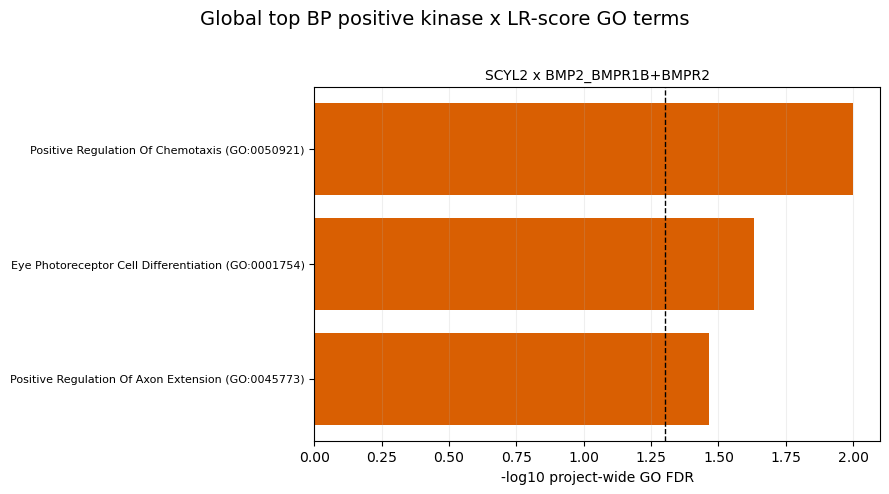

Saved BP negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_negative.png
Saved BP negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_negative.pdf
Saved BP negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_bp_negative.svg


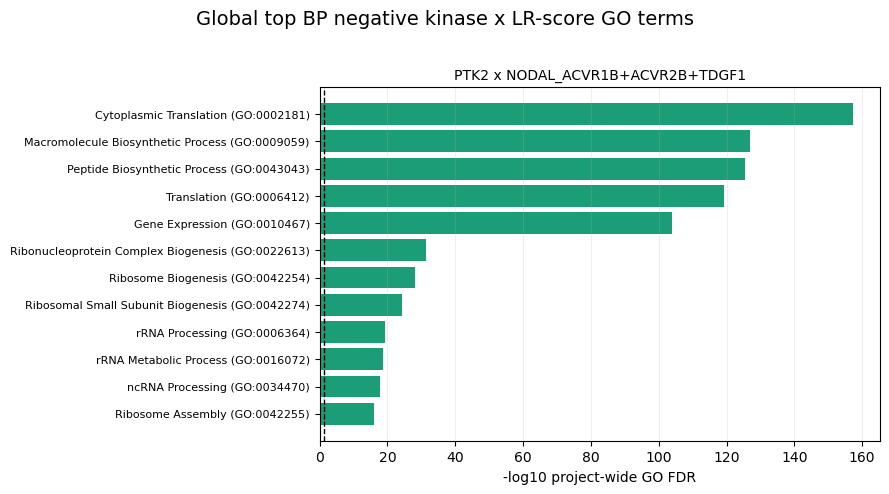

Saved MF positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_positive.png
Saved MF positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_positive.pdf
Saved MF positive GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_positive.svg


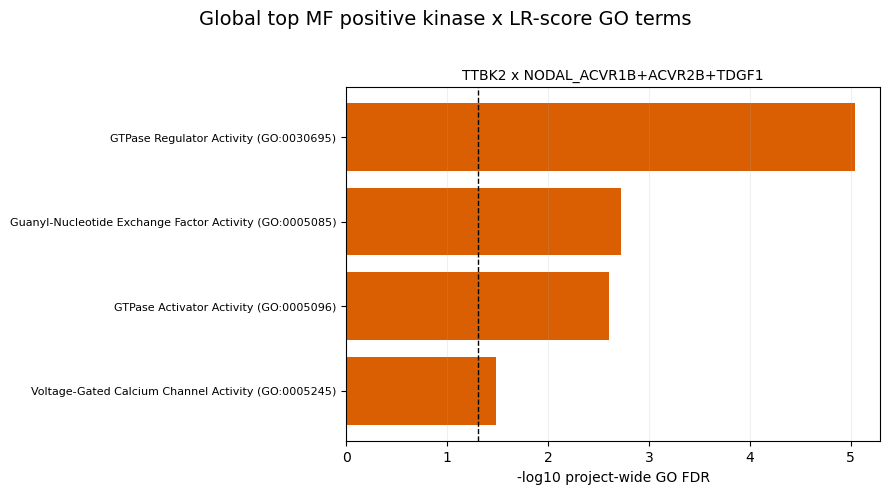

Saved MF negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_negative.png
Saved MF negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_negative.pdf
Saved MF negative GO panel: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_go_global_top_mf_negative.svg


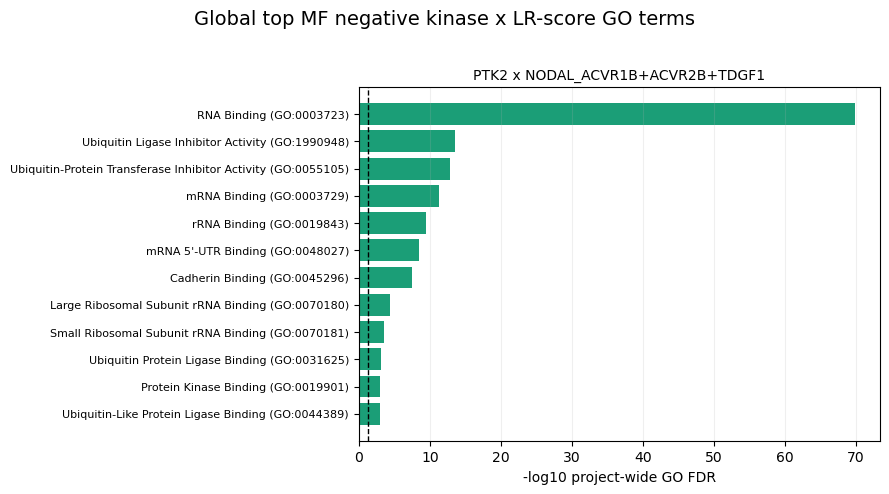

,ontology,direction,png,pdf,svg,n_terms_plotted,n_panels
0,BP,positive,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,174,1
1,BP,negative,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,432,1
2,MF,positive,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,34,1
3,MF,negative,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,/scratch/luvul_root/luvul0/luvul/kinase_cytosi...,351,1


Saved significant GO terms: /scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_eb_spatial_maps/kinase_go_target_lr_direction_union_across_radii_projectwide/kinase_lr_directional_projectwide_significant_go_terms.csv.gz


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,target,lr_var_name,direction,ontology,library,n_input_genes,ligand_name,receptor_name,lr_name,source_min_fdr_interaction_projectwide,source_median_abs_beta_interaction,status,error,fdr_go_projectwide_within_ontology_and_direction,minus_log10_projectwide_go_fdr,passes_projectwide_go_fdr
10456,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),75/93,4.181568e-162,3.587786e-159,0.0,0.0,1880.965909,698944.545811,RPL4;EIF4A1;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;...,PTK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,119,,,NODAL_ACVR1B+ACVR2B+TDGF1,8.015617e-10,0.119525,completed,NaN,4.022669e-158,157.395486,True
9556,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),70/93,9.062617e-145,6.679149e-142,0.0,0.0,1140.098441,378137.225931,RPL4;EIF4A1;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;...,MERTK,CPI-SS055E061C9,negative,BP,GO_Biological_Process_2023,123,,,FAM3C_LAMP1,1.304777e-11,0.208819,completed,NaN,4.359119e-141,140.360601,True
16348,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),62/93,1.367978e-132,8.358347e-130,0.0,0.0,1282.322581,389348.910179,RPL4;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;RPLP0;...,ROCK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,93,,,NODAL_ACVR1B+ACVR2B+TDGF1,4.691983e-06,0.111497,completed,NaN,4.386650e-129,128.357867,True
10457,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),76/183,5.621378e-131,2.411571e-128,0.0,0.0,326.629863,97960.238486,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...,PTK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,119,,,NODAL_ACVR1B+ACVR2B+TDGF1,8.015617e-10,0.119525,completed,NaN,1.351941e-127,126.869042,True
10458,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),73/158,1.421816e-129,4.066395e-127,0.0,0.0,369.592839,109651.373247,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...,PTK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,119,,,NODAL_ACVR1B+ACVR2B+TDGF1,8.015617e-10,0.119525,completed,NaN,2.735575e-126,125.562951,True
10459,GO_Biological_Process_2023,Translation (GO:0006412),77/234,2.805521e-123,6.017842e-121,0.0,0.0,230.322718,64993.933272,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...,PTK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,119,,,NODAL_ACVR1B+ACVR2B+TDGF1,8.015617e-10,0.119525,completed,NaN,4.498185e-120,119.346963,True
9557,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),68/158,1.382407e-115,5.094169e-113,0.0,0.0,271.821414,71889.549805,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...,MERTK,CPI-SS055E061C9,negative,BP,GO_Biological_Process_2023,123,,,FAM3C_LAMP1,1.304777e-11,0.208819,completed,NaN,1.899822e-112,111.721287,True
9558,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),70/183,8.844558e-115,2.172813e-112,0.0,0.0,231.003506,60665.559496,RPL4;RPL5;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;R...,MERTK,CPI-SS055E061C9,negative,BP,GO_Biological_Process_2023,123,,,FAM3C_LAMP1,1.304777e-11,0.208819,completed,NaN,1.063558e-111,110.973239,True
16349,GO_Biological_Process_2023,Macromolecule Biosynthetic Process (GO:0009059),64/183,1.096736e-112,3.350527e-110,0.0,0.0,366.975369,94605.219894,RPL4;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;RPLP0;...,ROCK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,93,,,NODAL_ACVR1B+ACVR2B+TDGF1,4.691983e-06,0.111497,completed,NaN,1.172288e-109,108.930966,True
16350,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),62/158,1.665065e-112,3.391182e-110,0.0,0.0,412.729167,106228.095168,RPL4;RPL30;RPL3;RPL32;RPL31;RPL34;RPLP1;RPLP0;...,ROCK2,CPI-CS040AEB4A0,negative,BP,GO_Biological_Process_2023,93,,,NODAL_ACVR1B+ACVR2B+TDGF1,4.691983e-06,0.111497,completed,NaN,1.601793e-109,108.795394,True


In [27]:
from hashlib import sha256
from statsmodels.stats.multitest import multipletests

try:
    import gseapy as gp
except ImportError as exc:
    raise ImportError('gseapy is required for kinase directional GO analysis. Install it in the active kernel environment.') from exc

KINASE_GO_OUTPUT_DIR = OUTPUT_DIR / 'kinase_go_target_lr_direction_union_across_radii_projectwide'
KINASE_GO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
KINASE_GO_CACHE_DIR = KINASE_GO_OUTPUT_DIR / 'enrichr_cache'
KINASE_GO_CACHE_DIR.mkdir(parents=True, exist_ok=True)

KINASE_GO_LIBRARIES = {
    'BP': 'GO_Biological_Process_2023',
    'MF': 'GO_Molecular_Function_2023',
}
KINASE_GO_MIN_GENES = 10
KINASE_GO_ALPHA = 0.05
KINASE_GO_TOP_TERMS_PER_PANEL = 12
KINASE_GO_MAX_PANELS = 24

projectwide_metadata = json.loads(PROJECTWIDE_FDR_POINTER.read_text())
if projectwide_metadata.get('status') != 'completed':
    raise RuntimeError(f'Project-wide FDR is not complete: {projectwide_metadata}')
projectwide_run_dir = Path(projectwide_metadata['run_dir'])
projectwide_event_path = projectwide_run_dir / 'projectwide_significant_interaction_events.csv.gz'
if not projectwide_event_path.is_file():
    raise FileNotFoundError(projectwide_event_path)

event_usecols = [
    'target', 'radius_um', 'lr_var_name', 'gene', 'beta_interaction',
    'fdr_interaction_projectwide', 'ligand_name', 'receptor_name', 'lr_name',
]
all_sig_events = pd.read_csv(projectwide_event_path, usecols=lambda c: c in event_usecols)
all_sig_events['target'] = all_sig_events['target'].astype(str).str.upper()
all_sig_events['radius_um'] = all_sig_events['radius_um'].astype(int)
all_sig_events['lr_var_name'] = all_sig_events['lr_var_name'].astype(str)
all_sig_events['gene'] = all_sig_events['gene'].astype(str).str.upper()
all_sig_events['beta_interaction'] = pd.to_numeric(all_sig_events['beta_interaction'], errors='coerce')
all_sig_events['fdr_interaction_projectwide'] = pd.to_numeric(all_sig_events['fdr_interaction_projectwide'], errors='coerce')
all_sig_events = all_sig_events.loc[
    all_sig_events['fdr_interaction_projectwide'].lt(MAX_PROJECTWIDE_FDR_INTERACTION)
    & all_sig_events['beta_interaction'].notna()
    & all_sig_events['beta_interaction'].ne(0)
].copy()
all_sig_events['sign'] = np.sign(all_sig_events['beta_interaction']).astype(int)

lr_meta_cols = [c for c in ['ligand_name', 'receptor_name', 'lr_name'] if c in all_sig_events.columns]
records = []
conflict_records = []
for (target, lr_var_name, gene), group in all_sig_events.groupby(['target', 'lr_var_name', 'gene'], dropna=False):
    signs = sorted(set(group['sign'].dropna().astype(int)))
    base = {
        'target': target,
        'lr_var_name': lr_var_name,
        'gene': gene,
        'supporting_radii': ','.join(map(str, sorted(group['radius_um'].unique()))),
        'n_supporting_radii': int(group['radius_um'].nunique()),
        'n_supporting_events': int(len(group)),
        'min_fdr_interaction_projectwide': float(group['fdr_interaction_projectwide'].min()),
        'mean_beta_interaction': float(group['beta_interaction'].mean()),
        'max_abs_beta_interaction': float(group['beta_interaction'].abs().max()),
    }
    for c in lr_meta_cols:
        base[c] = group[c].dropna().astype(str).iloc[0] if group[c].notna().any() else ''
    if signs == [1]:
        records.append({**base, 'direction': 'positive'})
    elif signs == [-1]:
        records.append({**base, 'direction': 'negative'})
    else:
        conflict_records.append({**base, 'direction': 'conflict', 'signs': ','.join(map(str, signs))})

directional_gene_support = pd.DataFrame(records)
directional_conflicts = pd.DataFrame(conflict_records)
directional_gene_support.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_gene_support.csv.gz', index=False, compression='gzip')
directional_conflicts.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_conflict_gene_audit.csv.gz', index=False, compression='gzip')

if directional_gene_support.empty:
    raise RuntimeError('No non-conflicting directional kinase x LR gene sets were available for GO.')

set_rows = []
for (target, lr_var_name, direction), group in directional_gene_support.groupby(['target', 'lr_var_name', 'direction'], dropna=False):
    genes = sorted(set(group['gene'].dropna().astype(str)))
    meta = group.iloc[0]
    set_rows.append({
        'target': target,
        'lr_var_name': lr_var_name,
        'direction': direction,
        'n_genes': len(genes),
        'genes': ';'.join(genes),
        'ligand_name': meta.get('ligand_name', ''),
        'receptor_name': meta.get('receptor_name', ''),
        'lr_name': meta.get('lr_name', lr_var_name),
        'n_gene_radius_support_rows': int(len(group)),
        'min_fdr_interaction_projectwide': float(group['min_fdr_interaction_projectwide'].min()),
        'median_abs_beta_interaction': float(group['max_abs_beta_interaction'].median()),
    })

gene_sets = pd.DataFrame(set_rows).sort_values(['n_genes', 'median_abs_beta_interaction'], ascending=[False, False], ignore_index=True)
gene_sets['eligible_for_go'] = gene_sets['n_genes'].ge(KINASE_GO_MIN_GENES)
gene_sets.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_gene_sets.csv', index=False)

print('Directional support rows:', len(directional_gene_support))
print('Directional conflicts excluded:', len(directional_conflicts))
print('Directional gene sets:', len(gene_sets))
print('Eligible GO gene sets:', int(gene_sets['eligible_for_go'].sum()))
display(gene_sets.head(30))


def _enrichr_cache_key(genes, library):
    payload = json.dumps({'genes': sorted(map(str, genes)), 'library': library, 'organism': 'human'}, sort_keys=True)
    return sha256(payload.encode('utf-8')).hexdigest()[:20]


def _run_cached_enrichr(genes, library, cache_dir):
    genes = sorted(set(str(g).upper() for g in genes if str(g).strip()))
    cache_path = cache_dir / f'{library}__{_enrichr_cache_key(genes, library)}.csv.gz'
    if cache_path.is_file():
        return pd.read_csv(cache_path)
    enr = gp.enrichr(gene_list=genes, gene_sets=library, organism='human', outdir=None, cutoff=1.0, no_plot=True)
    result = enr.results.copy() if enr.results is not None else pd.DataFrame()
    result.to_csv(cache_path, index=False, compression='gzip')
    return result


go_rows = []
for _, row in gene_sets.loc[gene_sets['eligible_for_go']].iterrows():
    genes = [g for g in str(row['genes']).split(';') if g]
    for ontology, library in KINASE_GO_LIBRARIES.items():
        print(f"GO {ontology}: {row['target']} x {row['lr_var_name']} x {row['direction']} ({len(genes)} genes)")
        try:
            enr = _run_cached_enrichr(genes, library, KINASE_GO_CACHE_DIR)
        except Exception as exc:
            go_rows.append({
                'target': row['target'],
                'lr_var_name': row['lr_var_name'],
                'direction': row['direction'],
                'ontology': ontology,
                'library': library,
                'status': 'failed',
                'error': repr(exc),
                'n_input_genes': len(genes),
            })
            continue
        if enr.empty:
            go_rows.append({
                'target': row['target'],
                'lr_var_name': row['lr_var_name'],
                'direction': row['direction'],
                'ontology': ontology,
                'library': library,
                'status': 'empty',
                'n_input_genes': len(genes),
            })
            continue
        enr = enr.copy()
        enr['target'] = row['target']
        enr['lr_var_name'] = row['lr_var_name']
        enr['direction'] = row['direction']
        enr['ontology'] = ontology
        enr['library'] = library
        enr['n_input_genes'] = len(genes)
        enr['ligand_name'] = row.get('ligand_name', '')
        enr['receptor_name'] = row.get('receptor_name', '')
        enr['lr_name'] = row.get('lr_name', row['lr_var_name'])
        enr['source_min_fdr_interaction_projectwide'] = row['min_fdr_interaction_projectwide']
        enr['source_median_abs_beta_interaction'] = row['median_abs_beta_interaction']
        enr['status'] = 'completed'
        go_rows.append(enr)

all_go = pd.concat([x if isinstance(x, pd.DataFrame) else pd.DataFrame([x]) for x in go_rows], ignore_index=True) if go_rows else pd.DataFrame()
p_col_candidates = ['P-value', 'P_value', 'P-value ', 'p_value', 'pvalue']
p_col = next((column for column in p_col_candidates if column in all_go.columns), None)
if not all_go.empty and p_col is not None:
    all_go[p_col] = pd.to_numeric(all_go[p_col], errors='coerce')
    all_go['fdr_go_projectwide_within_ontology_and_direction'] = np.nan
    completed_mask = all_go.get('status', pd.Series('', index=all_go.index)).eq('completed')
    testable = all_go.loc[completed_mask & all_go[p_col].notna()]
    for (ontology, direction), idx in testable.groupby(['ontology', 'direction']).groups.items():
        pvals = all_go.loc[idx, p_col].to_numpy(dtype=float)
        all_go.loc[idx, 'fdr_go_projectwide_within_ontology_and_direction'] = multipletests(pvals, method='fdr_bh')[1]
    all_go['minus_log10_projectwide_go_fdr'] = -np.log10(all_go['fdr_go_projectwide_within_ontology_and_direction'].clip(lower=1e-300))
    all_go['passes_projectwide_go_fdr'] = all_go['fdr_go_projectwide_within_ontology_and_direction'].lt(KINASE_GO_ALPHA)
else:
    if 'fdr_go_projectwide_within_ontology_and_direction' not in all_go.columns:
        all_go['fdr_go_projectwide_within_ontology_and_direction'] = np.nan
    if 'minus_log10_projectwide_go_fdr' not in all_go.columns:
        all_go['minus_log10_projectwide_go_fdr'] = np.nan
    if 'passes_projectwide_go_fdr' not in all_go.columns:
        all_go['passes_projectwide_go_fdr'] = False
    print('No Enrichr result table with a p-value column was returned; saving GO audit only.')

all_go_path = KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_go_results_with_projectwide_fdr.csv.gz'
all_go.to_csv(all_go_path, index=False, compression='gzip')
print('Saved GO results:', all_go_path)

if all_go.empty:
    print('No GO results returned.')
else:
    status_qc = all_go.get('status', pd.Series('unknown', index=all_go.index)).value_counts(dropna=False).rename_axis('status').reset_index(name='n_rows')
    status_qc.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_go_status_qc.csv', index=False)
    display(status_qc)
    completed = all_go.loc[all_go.get('status', pd.Series('', index=all_go.index)).eq('completed')].copy()
    if completed.empty or 'Term' not in completed.columns:
        print('No completed Enrichr term table was available for GO plotting. Check the status QC and cache directory.')
        completed = pd.DataFrame()

if not all_go.empty and not completed.empty:
    go_qc = (
        completed.groupby(['ontology', 'direction'], as_index=False)
        .agg(
            n_terms=('Term', 'size'),
            n_significant=('passes_projectwide_go_fdr', 'sum'),
            min_projectwide_go_fdr=('fdr_go_projectwide_within_ontology_and_direction', 'min'),
            n_gene_sets=('target', lambda x: int(completed.loc[x.index, ['target', 'lr_var_name', 'direction']].drop_duplicates().shape[0])),
        )
        .sort_values(['ontology', 'direction'], ignore_index=True)
    )
    go_qc.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_go_qc.csv', index=False)
    display(go_qc)

    def make_global_ontology_direction_go_panel(ontology, direction, color, max_panels=2):
        plot_source = completed.loc[
            completed['ontology'].eq(ontology)
            & completed['direction'].eq(direction)
            & completed['passes_projectwide_go_fdr']
        ].copy()
        if plot_source.empty:
            print(f'No {ontology} {direction} GO term passed project-wide GO FDR < {KINASE_GO_ALPHA}; plotting top near-threshold terms instead.')
            plot_source = (
                completed.loc[
                    completed['ontology'].eq(ontology)
                    & completed['direction'].eq(direction)
                ]
                .sort_values('fdr_go_projectwide_within_ontology_and_direction')
                .head(max_panels * KINASE_GO_TOP_TERMS_PER_PANEL)
                .copy()
            )
        else:
            plot_source = (
                plot_source.sort_values('fdr_go_projectwide_within_ontology_and_direction')
                .groupby(['target', 'lr_var_name'], group_keys=False)
                .head(KINASE_GO_TOP_TERMS_PER_PANEL)
                .copy()
            )

        if plot_source.empty:
            print(f'No {ontology} {direction} GO terms are available for plotting.')
            return None

        lr_label = plot_source.get('lr_name', plot_source['lr_var_name']).fillna(plot_source['lr_var_name']).astype(str)
        plot_source['model_label'] = plot_source['target'].astype(str) + ' x ' + lr_label
        panel_order = (
            plot_source.groupby(['model_label'], as_index=False)
            .agg(best_fdr=('fdr_go_projectwide_within_ontology_and_direction', 'min'))
            .sort_values('best_fdr')
            .head(max_panels)
        )
        panels = panel_order[['model_label']].to_dict('records')
        n_panels = len(panels)
        ncols = min(2, max(1, n_panels))
        nrows = int(np.ceil(n_panels / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, max(4.8, 4.5 * nrows)), squeeze=False)
        for ax in axes.ravel():
            ax.axis('off')
        for ax, panel in zip(axes.ravel(), panels):
            sub = plot_source.loc[
                plot_source['model_label'].eq(panel['model_label'])
            ].sort_values('fdr_go_projectwide_within_ontology_and_direction').head(KINASE_GO_TOP_TERMS_PER_PANEL)
            sub = sub.iloc[::-1].copy()
            ax.axis('on')
            values = -np.log10(sub['fdr_go_projectwide_within_ontology_and_direction'].clip(lower=1e-300))
            ax.barh(sub['Term'], values, color=color)
            ax.axvline(-np.log10(KINASE_GO_ALPHA), color='black', linestyle='--', linewidth=1)
            ax.set_title(panel['model_label'], fontsize=10)
            ax.set_xlabel('-log10 project-wide GO FDR')
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(axis='x', alpha=0.2)
        fig.suptitle(f'Global top {ontology} {direction} kinase x LR-score GO terms', fontsize=14, y=1.02)
        fig.tight_layout()
        prefix = f'kinase_lr_directional_go_global_top_{ontology.lower()}_{direction}'
        png_path = KINASE_GO_OUTPUT_DIR / f'{prefix}.png'
        pdf_path = KINASE_GO_OUTPUT_DIR / f'{prefix}.pdf'
        svg_path = KINASE_GO_OUTPUT_DIR / f'{prefix}.svg'
        fig.savefig(png_path, dpi=220, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        fig.savefig(svg_path, format='svg', bbox_inches='tight')
        print(f'Saved {ontology} {direction} GO panel:', png_path)
        print(f'Saved {ontology} {direction} GO panel:', pdf_path)
        print(f'Saved {ontology} {direction} GO panel:', svg_path)
        plt.show()
        return {
            'ontology': ontology,
            'direction': direction,
            'png': png_path,
            'pdf': pdf_path,
            'svg': svg_path,
            'n_terms_plotted': int(len(plot_source)),
            'n_panels': int(n_panels),
        }

    go_panel_outputs = []
    for ontology in ['BP', 'MF']:
        for direction, color in [('positive', '#d95f02'), ('negative', '#1b9e77')]:
            panel = make_global_ontology_direction_go_panel(ontology, direction, color=color, max_panels=1)
            if panel is not None:
                go_panel_outputs.append(panel)
    go_panel_outputs = pd.DataFrame(go_panel_outputs)
    if not go_panel_outputs.empty:
        go_panel_outputs.to_csv(KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_go_global_ontology_direction_panel_outputs.csv', index=False)
        display(go_panel_outputs)

    significant_terms = completed.loc[completed['passes_projectwide_go_fdr']].copy()
    significant_path = KINASE_GO_OUTPUT_DIR / 'kinase_lr_directional_projectwide_significant_go_terms.csv.gz'
    significant_terms.to_csv(significant_path, index=False, compression='gzip')
    print('Saved significant GO terms:', significant_path)
    display(significant_terms.sort_values('fdr_go_projectwide_within_ontology_and_direction').head(50))
